<a href="https://colab.research.google.com/github/sabeiaung8/Customer-Analysis-from-Market-Campaign/blob/main/Customer_Analysis_from_marketing_campaign.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from sklearn.preprocessing import LabelEncoder
from scipy import stats
import plotly.express as px

# Set the aesthetic style of the plots for consistency
sns.set_style("whitegrid")

# Data Analysis of Marketing Campaign

This notebook performs a step-by-step data analysis of the marketing campaign dataset.

In [6]:
from google.colab import files
import io

# Upload the dataset
print("Please upload the 'marketing_campaign.csv' file.")
uploaded = files.upload()

# Read the uploaded file into a DataFrame
for fn in uploaded.keys():
  print('User uploaded file "{name}" with length {length} bytes'.format(
      name=fn, length=len(uploaded[fn])))
  df = pd.read_csv(io.StringIO(uploaded[fn].decode('utf-8')), sep='\t')

# --- Initial Data Inspection ---
# Display the first 5 rows of the DataFrame
print("Initial DataFrame Head:")
display(df.head())

# Display information about the DataFrame (columns, data types, non-null values)
print("\nDataFrame Info:")
df.info()

# Display descriptive statistics for numerical columns
print("\nDescriptive Statistics:")
display(df.describe())

# --- Handling Missing Values ---
print("\nMissing values before imputation:")
missing_values_before = df.isnull().sum()
display(missing_values_before[missing_values_before > 0])

# Fill missing 'Income' values with the mean
df['Income'].fillna(df['Income'].mean(), inplace=True)

# Verify that there are no more missing values in 'Income'
print("\nMissing values after imputation:")
missing_values_after = df.isnull().sum()
display(missing_values_after[missing_values_after > 0])

# --- Feature Engineering ---
# Convert 'Dt_Customer' to datetime objects
df['Dt_Customer'] = pd.to_datetime(df['Dt_Customer'], format='%d-%m-%Y')

# Calculate 'Age' from 'Year_Birth'
df['Age'] = 2024 - df['Year_Birth'] # Assuming current year is 2024

# Drop constant columns Z_CostContact and Z_Revenue
df.drop(['Z_CostContact', 'Z_Revenue'], axis=1, inplace=True)

print("\nDataFrame Head after Feature Engineering:")
display(df.head())

Please upload the 'marketing_campaign.csv' file.


Saving marketing_campaign.csv to marketing_campaign.csv
User uploaded file "marketing_campaign.csv" with length 220188 bytes
Initial DataFrame Head:


,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,...,NumWebVisitsMonth,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Complain,Z_CostContact,Z_Revenue,Response
0,5524,1957,Graduation,Single,58138.0,0,0,04-09-2012,58,635,...,7,0,0,0,0,0,0,3,11,1
1,2174,1954,Graduation,Single,46344.0,1,1,08-03-2014,38,11,...,5,0,0,0,0,0,0,3,11,0
2,4141,1965,Graduation,Together,71613.0,0,0,21-08-2013,26,426,...,4,0,0,0,0,0,0,3,11,0
3,6182,1984,Graduation,Together,26646.0,1,0,10-02-2014,26,11,...,6,0,0,0,0,0,0,3,11,0
4,5324,1981,PhD,Married,58293.0,1,0,19-01-2014,94,173,...,5,0,0,0,0,0,0,3,11,0



DataFrame Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2240 entries, 0 to 2239
Data columns (total 29 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   ID                   2240 non-null   int64  
 1   Year_Birth           2240 non-null   int64  
 2   Education            2240 non-null   object 
 3   Marital_Status       2240 non-null   object 
 4   Income               2216 non-null   float64
 5   Kidhome              2240 non-null   int64  
 6   Teenhome             2240 non-null   int64  
 7   Dt_Customer          2240 non-null   object 
 8   Recency              2240 non-null   int64  
 9   MntWines             2240 non-null   int64  
 10  MntFruits            2240 non-null   int64  
 11  MntMeatProducts      2240 non-null   int64  
 12  MntFishProducts      2240 non-null   int64  
 13  MntSweetProducts     2240 non-null   int64  
 14  MntGoldProds         2240 non-null   int64  
 15  NumDealsPurchases    

,ID,Year_Birth,Income,Kidhome,Teenhome,Recency,MntWines,MntFruits,MntMeatProducts,MntFishProducts,...,NumWebVisitsMonth,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Complain,Z_CostContact,Z_Revenue,Response
count,2240.000000,2240.000000,2216.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,...,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.0,2240.0,2240.000000
mean,5592.159821,1968.805804,52247.251354,0.444196,0.506250,49.109375,303.935714,26.302232,166.950000,37.525446,...,5.316518,0.072768,0.074554,0.072768,0.064286,0.013393,0.009375,3.0,11.0,0.149107
std,3246.662198,11.984069,25173.076661,0.538398,0.544538,28.962453,336.597393,39.773434,225.715373,54.628979,...,2.426645,0.259813,0.262728,0.259813,0.245316,0.114976,0.096391,0.0,0.0,0.356274
min,0.000000,1893.000000,1730.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,3.0,11.0,0.000000
25%,2828.250000,1959.000000,35303.000000,0.000000,0.000000,24.000000,23.750000,1.000000,16.000000,3.000000,...,3.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,3.0,11.0,0.000000
50%,5458.500000,1970.000000,51381.500000,0.000000,0.000000,49.000000,173.500000,8.000000,67.000000,12.000000,...,6.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,3.0,11.0,0.000000
75%,8427.750000,1977.000000,68522.000000,1.000000,1.000000,74.000000,504.250000,33.000000,232.000000,50.000000,...,7.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,3.0,11.0,0.000000
max,11191.000000,1996.000000,666666.000000,2.000000,2.000000,99.000000,1493.000000,199.000000,1725.000000,259.000000,...,20.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,3.0,11.0,1.000000


...


Missing values after imputation:


/tmp/ipykernel_1218/1597623753.py:33: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['Income'].fillna(df['Income'].mean(), inplace=True)


,0



DataFrame Head after Feature Engineering:


,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,...,NumStorePurchases,NumWebVisitsMonth,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Complain,Response,Age
0,5524,1957,Graduation,Single,58138.0,0,0,2012-09-04,58,635,...,4,7,0,0,0,0,0,0,1,67
1,2174,1954,Graduation,Single,46344.0,1,1,2014-03-08,38,11,...,2,5,0,0,0,0,0,0,0,70
2,4141,1965,Graduation,Together,71613.0,0,0,2013-08-21,26,426,...,10,4,0,0,0,0,0,0,0,59
3,6182,1984,Graduation,Together,26646.0,1,0,2014-02-10,26,11,...,4,6,0,0,0,0,0,0,0,40
4,5324,1981,PhD,Married,58293.0,1,0,2014-01-19,94,173,...,6,5,0,0,0,0,0,0,0,43


In [7]:
print("Missing values after all preprocessing:")
missing_values_final = df.isnull().sum()
display(missing_values_final[missing_values_final > 0])

if missing_values_final.sum() == 0:
    print("No missing values found in the dataset.")
else:
    print("Missing values still present in the dataset.")

Missing values after all preprocessing:


,0


No missing values found in the dataset.


### Exploring Categorical Features

Let's visualize the distribution of categorical variables like `Education` and `Marital_Status` to understand the customer demographics.

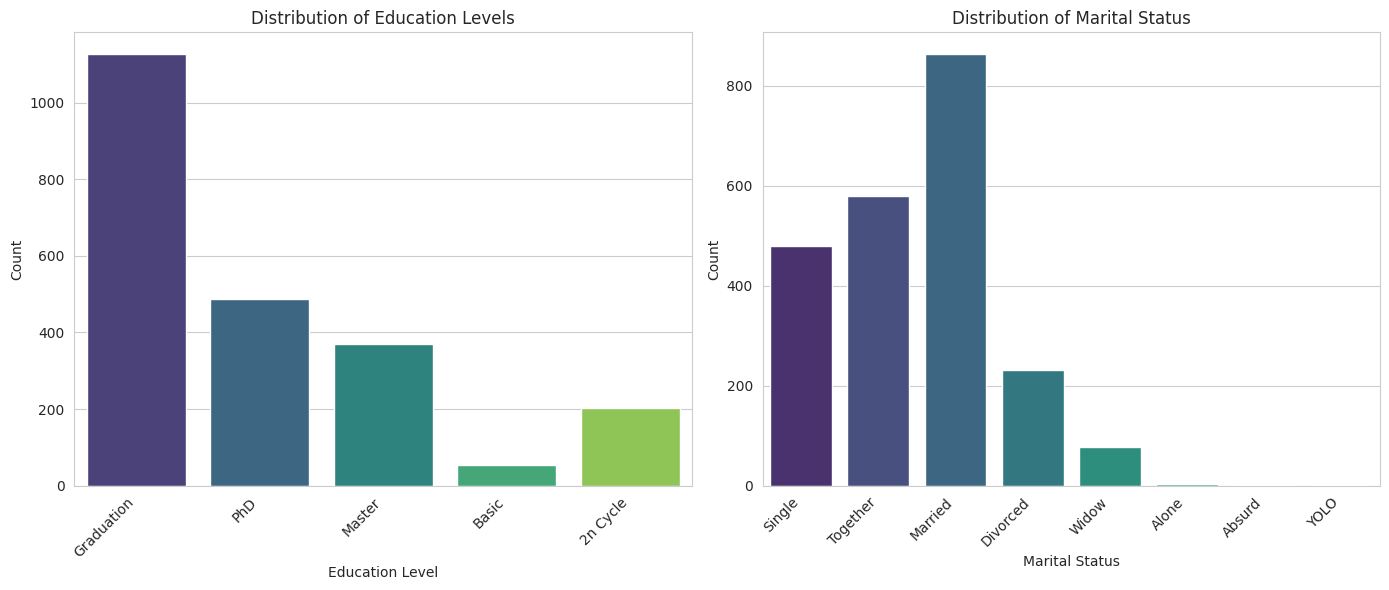

In [ ]:
plt.figure(figsize=(14, 6))

plt.subplot(1, 2, 1)
sns.countplot(data=df, x='Education', hue='Education', palette='viridis', legend=False)
plt.title('Distribution of Education Levels')
plt.xlabel('Education Level')
plt.ylabel('Count')
plt.xticks(rotation=45, ha='right')

plt.subplot(1, 2, 2)
sns.countplot(data=df, x='Marital_Status', hue='Marital_Status', palette='viridis', legend=False)
plt.title('Distribution of Marital Status')
plt.xlabel('Marital Status')
plt.ylabel('Count')
plt.xticks(rotation=45, ha='right')

plt.tight_layout()
plt.show()

### Analyzing Spending Habits

To understand customer spending, we will create a new feature `TotalMnt` by summing up all the `Mnt` (mount spent) columns. We will then visualize its distribution.

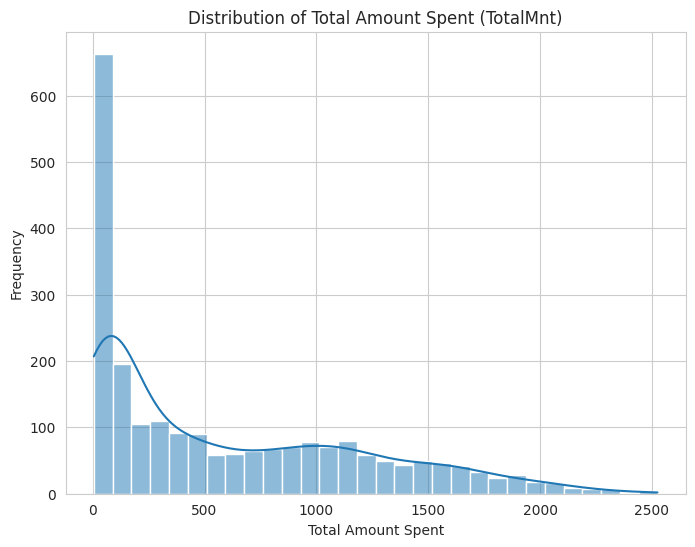

In [ ]:
# Create a new feature for total amount spent
df['TotalMnt'] = df['MntWines'] + df['MntFruits'] + df['MntMeatProducts'] + \
                 df['MntFishProducts'] + df['MntSweetProducts'] + df['MntGoldProds']

# Visualize the distribution of TotalMnt
plt.figure(figsize=(8, 6))
sns.histplot(df['TotalMnt'], kde=True, bins=30)
plt.title('Distribution of Total Amount Spent (TotalMnt)')
plt.xlabel('Total Amount Spent')
plt.ylabel('Frequency')
plt.show()

### Correlation Analysis

To understand the relationships between numerical features, we will compute and visualize the correlation matrix.

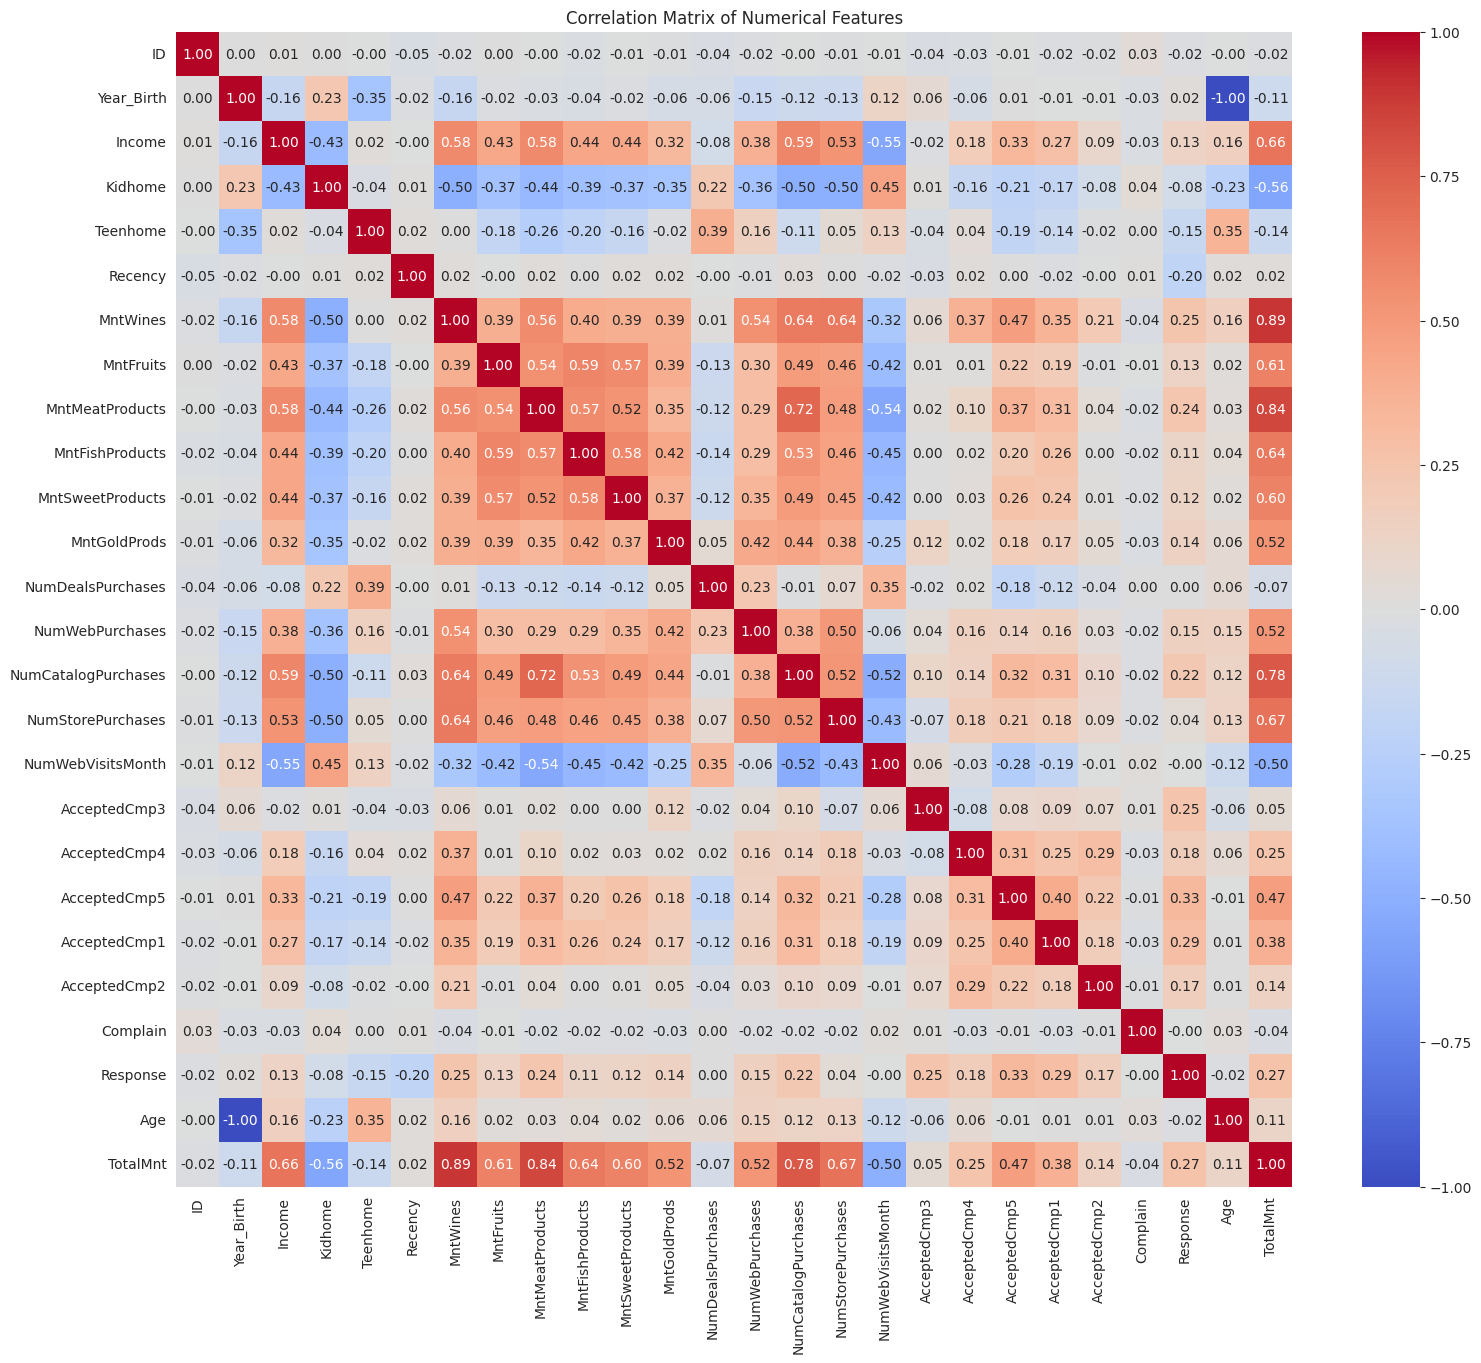

In [ ]:
# Select only numerical columns for correlation analysis
numerical_cols = df.select_dtypes(include=['int64', 'float64']).columns
correlation_matrix = df[numerical_cols].corr()

# Plotting the heatmap
plt.figure(figsize=(18, 15))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Matrix of Numerical Features')
plt.show()

### Comparative Analysis of Spending Habits

To understand how spending varies across different customer segments, we will compare the `TotalMnt` across `Education` levels and `Marital_Status` using box plots.

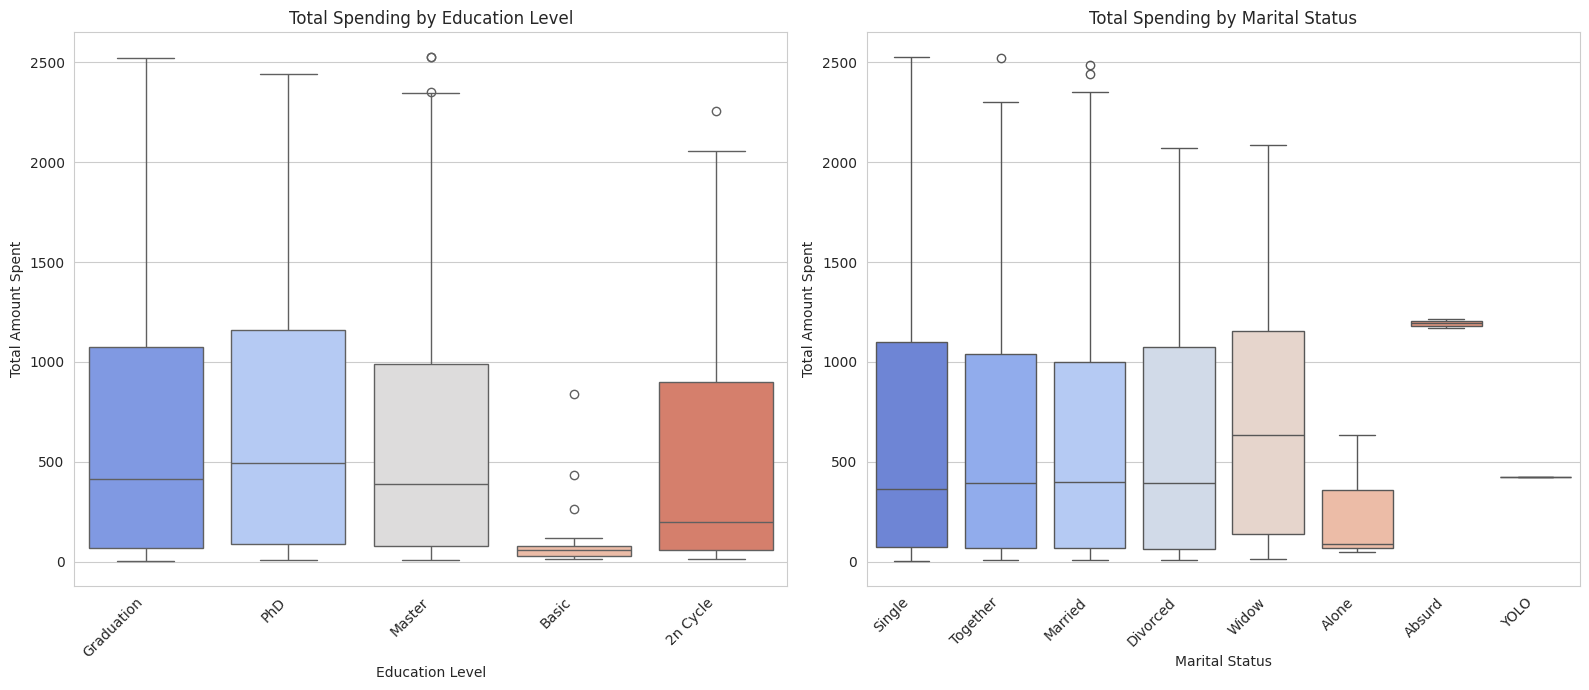

In [ ]:
plt.figure(figsize=(16, 7))

plt.subplot(1, 2, 1)
sns.boxplot(data=df, x='Education', y='TotalMnt', hue='Education', palette='coolwarm', legend=False)
plt.title('Total Spending by Education Level')
plt.xlabel('Education Level')
plt.ylabel('Total Amount Spent')
plt.xticks(rotation=45, ha='right')

plt.subplot(1, 2, 2)
sns.boxplot(data=df, x='Marital_Status', y='TotalMnt', hue='Marital_Status', palette='coolwarm', legend=False)
plt.title('Total Spending by Marital Status')
plt.xlabel('Marital Status')
plt.ylabel('Total Amount Spent')
plt.xticks(rotation=45, ha='right')

plt.tight_layout()
plt.show()

### Key Insights from Data Analysis

Based on our exploratory data analysis and correlation analysis, here are some key insights:

1.  **Income Distribution**: The income distribution is right-skewed, with most customers earning in the mid-range and a few high-income outliers. This suggests potential for segmenting customers by income level.
2.  **Age Distribution**: The age distribution indicates a significant portion of customers are in their middle to older age range, with fewer younger customers. This might influence product offerings and marketing channels.
3.  **Education Levels**: The majority of customers have 'Graduation' as their highest education, followed by 'PhD' and 'Master'. Customers with higher education levels (e.g., PhD, Master, Graduation) tend to have higher average spending (`TotalMnt`) compared to those with basic or 2n Cycle education.
4.  **Marital Status**: 'Married' and 'Together' represent the largest marital status groups. Single customers, particularly those with 'Widow' or 'Divorced' status, show higher average spending, while those with 'Absurd' or 'Alone' status show lower spending but their counts are very low, so they might not be statistically significant. Customers in 'Married' or 'Together' categories, despite being larger groups, tend to have slightly lower average spending than 'Single' or 'Divorced' customers, possibly due to family responsibilities affecting discretionary spending.
5.  **Spending Habits**: Wines are the most purchased product category, followed by meat products. Fruits, fish, and sweet products have lower spending. `TotalMnt` shows a wide range, indicating diverse spending behaviors among customers.
6.  **Children at Home**: The presence of `Kidhome` and `Teenhome` shows a negative correlation with spending across most product categories. Customers with more children at home tend to spend less on the analyzed product categories, likely due to budget constraints or different household priorities.
7.  **Campaign Success**: Acceptance of past campaigns (`AcceptedCmp` columns) generally correlates positively with spending (`Mnt` categories) and `Income`, suggesting that successful campaigns effectively target customers with higher purchasing power or those already inclined to spend.
8.  **Web Visits**: `NumWebVisitsMonth` shows a slight negative correlation with spending, which could imply that customers who make more in-store or catalog purchases might visit the website less frequently, or vice versa.

### Recommendations for Marketing Campaign

Based on the insights, here are some recommendations for future marketing campaigns:

1.  **Targeted Campaigns by Income and Education**: Given the positive correlation between `Income`, `Education`, and `TotalMnt`, tailor high-value product campaigns towards higher-income customers and those with advanced degrees.
2.  **Product-Specific Promotions**: Wines and meat products are popular. Focus on promoting these aggressively while also creating targeted campaigns to boost sales for lower-performing categories like fruits, fish, and sweet products. This could involve bundled offers or special discounts.
3.  **Family-Focused Strategies**: For customers with `Kidhome` or `Teenhome`, consider offering family-sized product bundles or budget-friendly options. Marketing messages could emphasize convenience or value for families, rather than luxury products.
4.  **Leverage Marital Status**: Develop specific campaigns for 'Single' and 'Divorced' customers, who show higher individual spending, potentially offering premium or personal indulgence products. For 'Married' and 'Together' groups, focus on shared experiences or household essentials.
5.  **Optimize Campaign Channels**: Analyze the correlation between `NumWebPurchases`, `NumCatalogPurchases`, `NumStorePurchases`, and `NumWebVisitsMonth` to determine the most effective channels for different customer segments. For example, if high spenders prefer catalog purchases, invest more in high-quality print catalogs for that segment.
6.  **Customer Lifecycle Management**: Consider the `Age` of customers. Older, more established customers might respond well to loyalty programs and exclusive offers, while younger segments might be attracted by digital-first campaigns and trendy products.
7.  **Address Low-Spending Categories**: Investigate why spending is lower in certain categories (e.g., fruits, fish). Is it price, variety, quality, or lack of awareness? Conduct surveys or A/B tests to find out and adjust strategy accordingly.
8.  **Loyalty Programs**: Develop loyalty programs that reward high-spending customers, encouraging repeat purchases and increasing customer lifetime value.

### Customer Segmentation using K-Means Clustering

To identify distinct customer segments, we will employ K-Means clustering. This involves:
1.  Selecting relevant numerical features for clustering.
2.  Scaling these features to ensure no single feature dominates the clustering process.
3.  Determining the optimal number of clusters using the Elbow Method.
4.  Applying the K-Means algorithm.
5.  Analyzing the characteristics of each resulting cluster.

In [ ]:
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt
import seaborn as sns

# Select features for clustering.
# Exclude ID, Year_Birth (Age is derived), Dt_Customer (converted to datetime), Z_CostContact, Z_Revenue (dropped)
# Include numerical features relevant to spending, purchasing behavior, demographics.
features_for_clustering = [
    'Income', 'Age', 'Kidhome', 'Teenhome', 'Recency',
    'MntWines', 'MntFruits', 'MntMeatProducts', 'MntFishProducts', 'MntSweetProducts', 'MntGoldProds',
    'NumDealsPurchases', 'NumWebPurchases', 'NumCatalogPurchases', 'NumStorePurchases', 'NumWebVisitsMonth',
    'AcceptedCmp1', 'AcceptedCmp2', 'AcceptedCmp3', 'AcceptedCmp4', 'AcceptedCmp5', 'Response', 'Complain',
    'TotalMnt' # The newly engineered total spending feature
]

# Ensure all selected features exist in the DataFrame
existing_features = [f for f in features_for_clustering if f in df.columns]

X = df[existing_features]

# Handle potential missing values in the selected features by filling with the mean
X = X.fillna(X.mean())

# Scale the features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

display(X.head())

,Income,Age,Kidhome,Teenhome,Recency,MntWines,MntFruits,MntMeatProducts,MntFishProducts,MntSweetProducts,...,NumStorePurchases,NumWebVisitsMonth,AcceptedCmp1,AcceptedCmp2,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,Response,Complain,TotalMnt
0,58138.0,67,0,0,58,635,88,546,172,88,...,4,7,0,0,0,0,0,1,0,1617
1,46344.0,70,1,1,38,11,1,6,2,1,...,2,5,0,0,0,0,0,0,0,27
2,71613.0,59,0,0,26,426,49,127,111,21,...,10,4,0,0,0,0,0,0,0,776
3,26646.0,40,1,0,26,11,4,20,10,3,...,4,6,0,0,0,0,0,0,0,53
4,58293.0,43,1,0,94,173,43,118,46,27,...,6,5,0,0,0,0,0,0,0,422


#### Determining Optimal Number of Clusters (Elbow Method)

The Elbow Method helps determine the optimal number of clusters by plotting the within-cluster sum of squares (WCSS) against the number of clusters. The 'elbow' point in the plot usually indicates the most appropriate number of clusters.

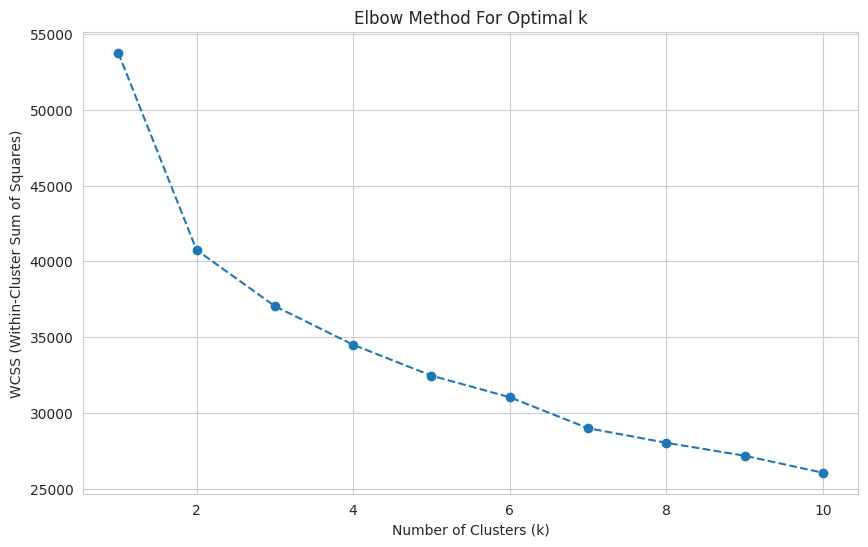

In [ ]:
wcss = []
for i in range(1, 11):
    kmeans = KMeans(n_clusters=i, init='k-means++', random_state=42, n_init=10)
    kmeans.fit(X_scaled)
    wcss.append(kmeans.inertia_)

plt.figure(figsize=(10, 6))
plt.plot(range(1, 11), wcss, marker='o', linestyle='--')
plt.title('Elbow Method For Optimal k')
plt.xlabel('Number of Clusters (k)')
plt.ylabel('WCSS (Within-Cluster Sum of Squares)')
plt.grid(True)
plt.show()

#### Applying K-Means Clustering

Based on the Elbow Method, let's assume `k=4` (or another appropriate number identified from the plot) as the optimal number of clusters. We will now apply K-Means with this number of clusters and add the cluster labels back to our original DataFrame.

In [ ]:
# Apply K-Means with the chosen number of clusters (e.g., k=4 based on a typical elbow point)
k = 4  # You might adjust this based on the Elbow Method plot above
kmeans = KMeans(n_clusters=k, init='k-means++', random_state=42, n_init=10)
clusters = kmeans.fit_predict(X_scaled)
df['Cluster'] = clusters

print(f"Number of customers in each cluster (k={k}):")
display(df['Cluster'].value_counts().sort_index())

Number of customers in each cluster (k=4):


,count
Cluster,
0,439
1,1040
2,173
3,588


#### Analyzing Customer Segments

Now, let's analyze the characteristics of each cluster by looking at the mean values of the original (unscaled) features for each segment. This will help us understand what makes each customer segment unique.

In [ ]:
# Group by cluster and calculate the mean of the original features
cluster_analysis = df.groupby('Cluster')[existing_features].mean()

display(cluster_analysis)

,Income,Age,Kidhome,Teenhome,Recency,MntWines,MntFruits,MntMeatProducts,MntFishProducts,MntSweetProducts,...,NumStorePurchases,NumWebVisitsMonth,AcceptedCmp1,AcceptedCmp2,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,Response,Complain,TotalMnt
Cluster,,,,,,,,,,,,,,,,,,,,,
0,74375.974383,56.061503,0.050114,0.220957,49.621868,509.574032,72.435080,438.949886,106.275626,70.733485,...,8.412301,2.947608,0.111617,0.000000,0.061503,0.027335,0.000000,0.175399,0.006834,1276.840547
1,35060.145208,52.412500,0.800000,0.442308,49.498077,41.792308,5.000962,23.473077,7.242308,5.074038,...,3.210577,6.467308,0.000962,0.001923,0.074038,0.008654,0.000000,0.092308,0.012500,97.935577
2,81469.985565,54.485549,0.052023,0.132948,49.872832,878.734104,55.942197,466.242775,76.485549,65.086705,...,8.213873,3.052023,0.439306,0.127168,0.138728,0.398844,0.930636,0.578035,0.005780,1619.872832
3,57527.094829,59.675170,0.224490,0.942177,47.814626,444.945578,20.814626,129.586735,28.295918,22.163265,...,7.681973,5.715986,0.030612,0.010204,0.059524,0.130952,0.003401,0.103741,0.006803,704.700680


#### Visualizing Cluster Characteristics

To further understand the clusters, we can visualize some key features across the segments, such as `Income`, `Age`, and `TotalMnt`.

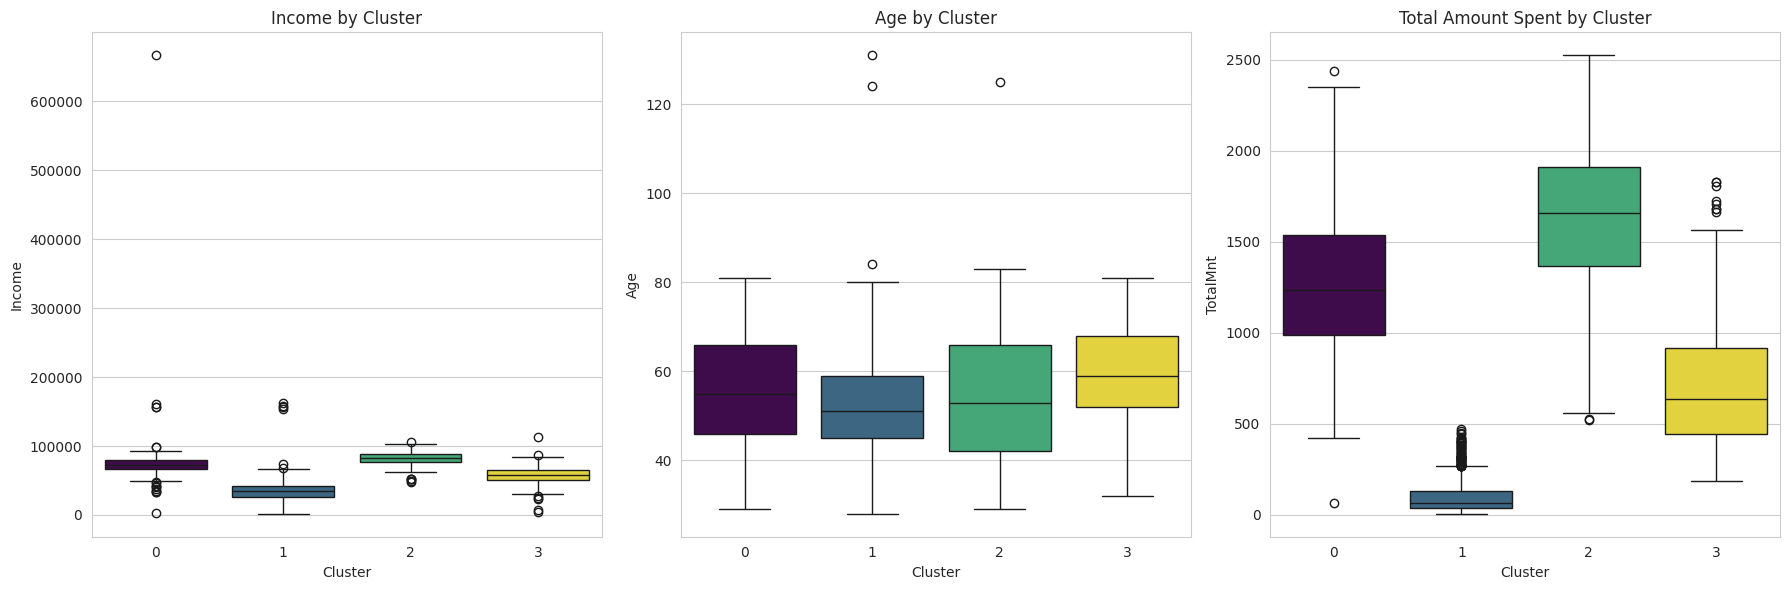

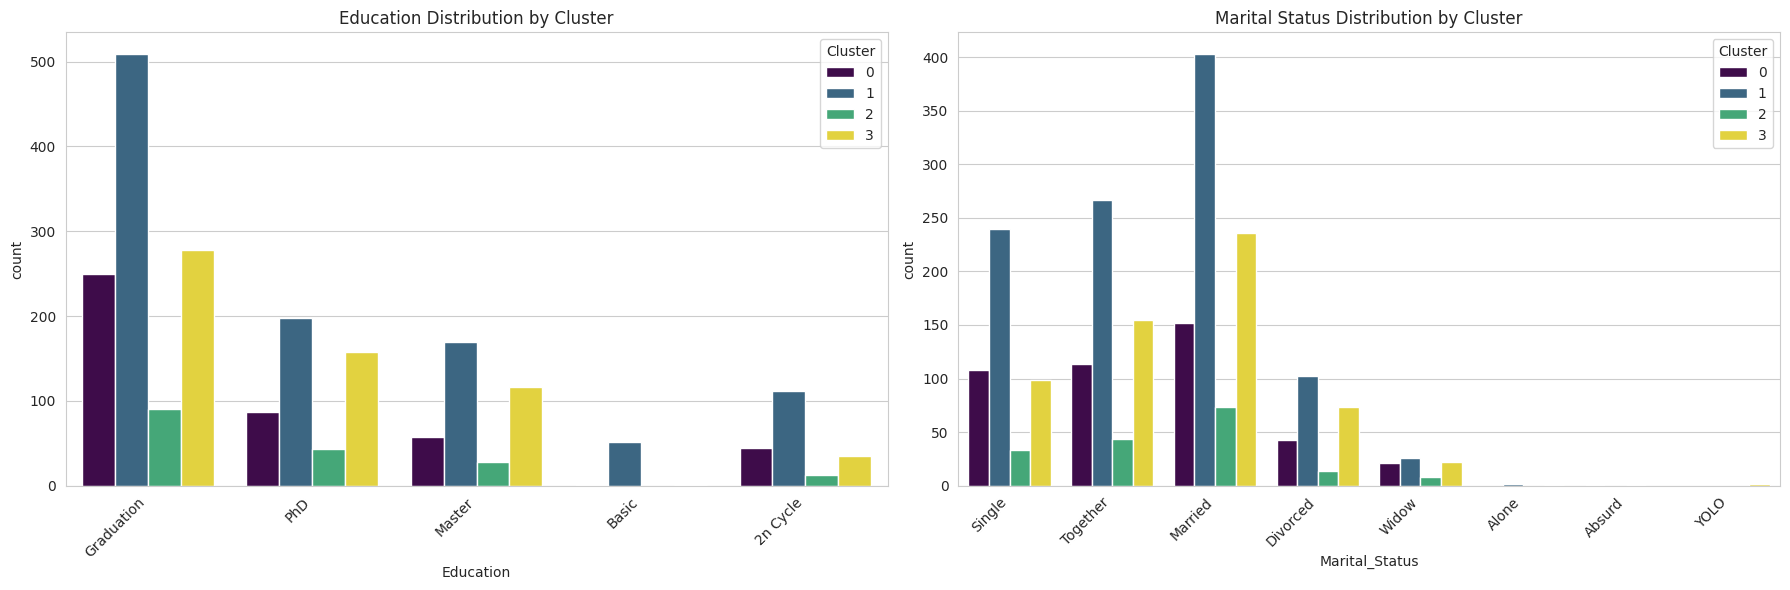

In [ ]:
plt.figure(figsize=(18, 6))

plt.subplot(1, 3, 1)
sns.boxplot(x='Cluster', y='Income', data=df, hue='Cluster', palette='viridis', legend=False)
plt.title('Income by Cluster')

plt.subplot(1, 3, 2)
sns.boxplot(x='Cluster', y='Age', data=df, hue='Cluster', palette='viridis', legend=False)
plt.title('Age by Cluster')

plt.subplot(1, 3, 3)
sns.boxplot(x='Cluster', y='TotalMnt', data=df, hue='Cluster', palette='viridis', legend=False)
plt.title('Total Amount Spent by Cluster')

plt.tight_layout()
plt.show()

# You can also visualize categorical features if needed, for example, Education and Marital_Status
plt.figure(figsize=(18, 6))

plt.subplot(1, 2, 1)
sns.countplot(data=df, x='Education', hue='Cluster', palette='viridis')
plt.title('Education Distribution by Cluster')
plt.xticks(rotation=45, ha='right')

plt.subplot(1, 2, 2)
sns.countplot(data=df, x='Marital_Status', hue='Cluster', palette='viridis')
plt.title('Marital Status Distribution by Cluster')
plt.xticks(rotation=45, ha='right')

plt.tight_layout()
plt.show()

### Further Investigation into Specific Features/Relationships

To delve deeper into specific relationships, we will use a regression plot to visualize the correlation between `Income` and `TotalMnt`. This can highlight how a customer's income influences their overall spending.

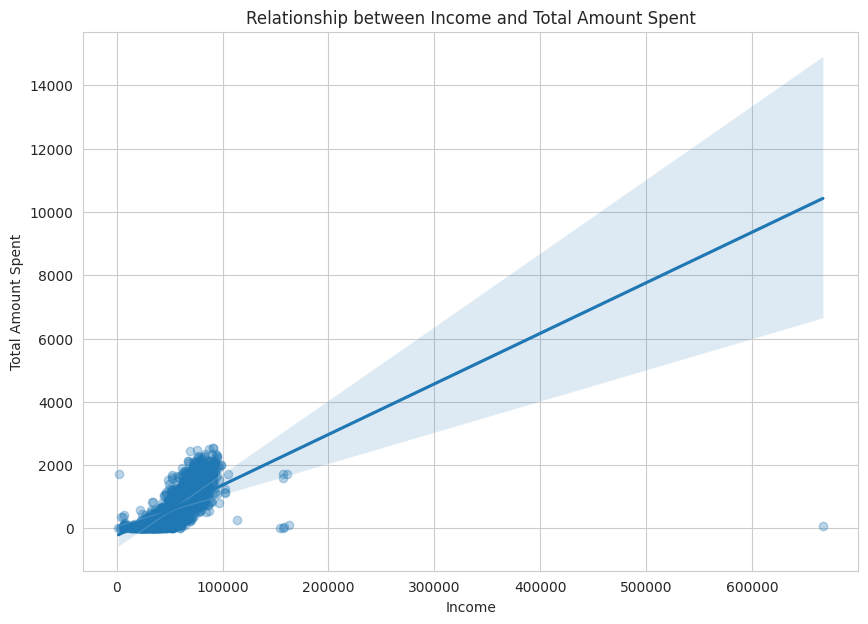

In [ ]:
plt.figure(figsize=(10, 7))
sns.regplot(x='Income', y='TotalMnt', data=df, scatter_kws={'alpha':0.3})
plt.title('Relationship between Income and Total Amount Spent')
plt.xlabel('Income')
plt.ylabel('Total Amount Spent')
plt.grid(True)
plt.show()

### Interactive Visualizations with Plotly

To allow for more dynamic and exploratory data analysis, we will create interactive visualizations using Plotly. These visualizations can help in identifying patterns and relationships that might not be immediately apparent in static plots.

In [ ]:
import plotly.express as px

# Scatter plot of Income vs. TotalMnt, colored by Cluster
fig = px.scatter(df, x='Income', y='TotalMnt', color='Cluster',
                 hover_data=['Age', 'Education', 'Marital_Status', 'Kidhome', 'Teenhome'],
                 title='Income vs. Total Amount Spent by Customer Cluster')
fig.show()

# Interactive bar chart for product spending by cluster
mnt_cols = ['MntWines', 'MntFruits', 'MntMeatProducts', 'MntFishProducts', 'MntSweetProducts', 'MntGoldProds']
cluster_spending = df.groupby('Cluster')[mnt_cols].mean().reset_index()
cluster_spending_melted = cluster_spending.melt(id_vars=['Cluster'], var_name='Product Category', value_name='Average Spending')

fig_bar = px.bar(cluster_spending_melted, x='Product Category', y='Average Spending', color='Cluster',
                 barmode='group', title='Average Spending per Product Category by Cluster')
fig_bar.show()


### Advanced Statistical Tests: Comparing Spending Habits

To conduct advanced statistical tests, we will use an independent samples t-test to compare the mean `TotalMnt` (total amount spent) between different groups. For example, we can compare customers with children (`Kidhome` > 0 or `Teenhome` > 0) versus those without children (`Kidhome` == 0 and `Teenhome` == 0).

In [ ]:
from scipy import stats

# Define groups: Customers with children vs. customers without children
customers_with_children = df[(df['Kidhome'] > 0) | (df['Teenhome'] > 0)]
customers_without_children = df[(df['Kidhome'] == 0) & (df['Teenhome'] == 0)]

# Perform independent samples t-test on 'TotalMnt'
t_stat, p_value = stats.ttest_ind(
    customers_with_children['TotalMnt'],
    customers_without_children['TotalMnt'],
    equal_var=False  # Assuming unequal variances
)

print(f"T-statistic: {t_stat:.3f}")
print(f"P-value: {p_value:.3e}")

if p_value < 0.05:
    print("\nInterpretation: The difference in total spending between customers with and without children is statistically significant.")
else:
    print("\nInterpretation: The difference in total spending between customers with and without children is NOT statistically significant.")

# We can also compare spending across different Education levels using ANOVA, but for simplicity, we'll stick to t-test for now.
print("\nMean TotalMnt for customers with children:", customers_with_children['TotalMnt'].mean())
print("Mean TotalMnt for customers without children:", customers_without_children['TotalMnt'].mean())

T-statistic: -25.071
P-value: 1.778e-105

Interpretation: The difference in total spending between customers with and without children is statistically significant.

Mean TotalMnt for customers with children: 406.57990012484396
Mean TotalMnt for customers without children: 1106.0297805642633


### Predictive Modeling: Predicting Campaign Response

To predict customer response to a campaign (e.g., the `Response` column), we will use a RandomForestClassifier. This process involves:
1.  **Feature Selection**: Identifying relevant features for prediction.
2.  **Data Preprocessing**: Handling categorical variables and splitting the data.
3.  **Model Training**: Training a RandomForestClassifier.
4.  **Model Evaluation**: Assessing the model's performance.

In [12]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from sklearn.preprocessing import LabelEncoder

# Prepare data for predictive modeling
# Target variable
y = df['Response']

# Features: Exclude ID, Z_CostContact, Z_Revenue, and the target 'Response' itself
# Also drop 'Dt_Customer', 'Year_Birth' (Age is derived), 'TotalMnt' (to avoid data leakage if TotalMnt is influenced by Response in real data)
# And the newly added 'Cluster' for general prediction, though it could be a feature for advanced models

features_for_prediction = df.drop(
    ['ID', 'Response', 'Z_CostContact', 'Z_Revenue', 'Dt_Customer', 'Year_Birth', 'TotalMnt', 'Cluster'],
    axis=1, errors='ignore'
)

# Handle categorical features using one-hot encoding
features_for_prediction = pd.get_dummies(features_for_prediction, columns=['Education', 'Marital_Status'], drop_first=True)

X_pred = features_for_prediction

# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X_pred, y, test_size=0.3, random_state=42, stratify=y)

print("Shape of X_train:", X_train.shape)
print("Shape of X_test:", X_test.shape)
print("Shape of y_train:", y_train.shape)
print("Shape of y_test:", y_test.shape)

display(X_train.head())

Shape of X_train: (1568, 33)
Shape of X_test: (672, 33)
Shape of y_train: (1568,)
Shape of y_test: (672,)


,Income,Kidhome,Teenhome,Recency,MntWines,MntFruits,MntMeatProducts,MntFishProducts,MntSweetProducts,MntGoldProds,...,Education_Graduation,Education_Master,Education_PhD,Marital_Status_Alone,Marital_Status_Divorced,Marital_Status_Married,Marital_Status_Single,Marital_Status_Together,Marital_Status_Widow,Marital_Status_YOLO
1986,57113.0,1,1,45,182,4,33,0,2,42,...,True,False,False,False,False,True,False,False,False,False
370,35684.0,1,0,66,10,4,7,0,6,3,...,False,False,False,False,False,True,False,False,False,False
2172,60934.0,0,1,41,224,155,155,192,93,54,...,True,False,False,False,False,False,False,True,False,False
2212,38054.0,1,1,24,23,2,17,2,1,0,...,False,True,False,False,True,False,False,False,False,False
1460,64866.0,0,1,9,508,5,21,7,5,10,...,False,True,False,False,False,False,False,False,True,False


#### Training the RandomForestClassifier

Now, we will train a RandomForestClassifier model and make predictions on the test set.

Classification Report:
              precision    recall  f1-score   support

           0       0.88      0.99      0.93       572
           1       0.77      0.23      0.35       100

    accuracy                           0.88       672
   macro avg       0.82      0.61      0.64       672
weighted avg       0.86      0.88      0.84       672

Confusion Matrix:
[[565   7]
 [ 77  23]]
Accuracy Score: 0.875


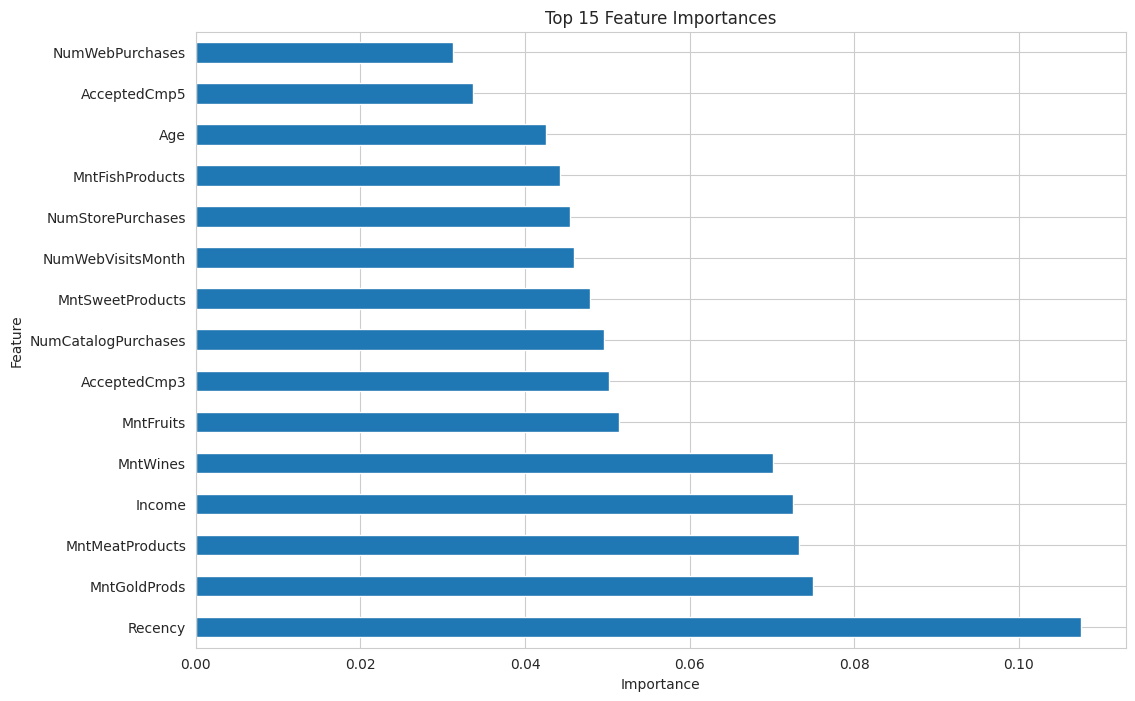

In [14]:
# Initialize and train the RandomForestClassifier
rf_classifier = RandomForestClassifier(n_estimators=100, random_state=42, class_weight='balanced') # Using class_weight due to potential imbalance in 'Response'
rf_classifier.fit(X_train, y_train)

# Make predictions on the test set
y_pred = rf_classifier.predict(X_test)

print("Classification Report:")
print(classification_report(y_test, y_pred))

print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred))

print("Accuracy Score:", accuracy_score(y_test, y_pred))

# Feature Importance
feature_importances = pd.Series(rf_classifier.feature_importances_, index=X_train.columns)
plt.figure(figsize=(12, 8))
feature_importances.nlargest(15).plot(kind='barh')
plt.title('Top 15 Feature Importances')
plt.xlabel('Importance')
plt.ylabel('Feature')
plt.show()

### Correlation Heatmap for Top Features Related to Campaign Response

To further understand the relationships between the most important features and the campaign `Response`, we will generate a correlation heatmap focusing on these features.

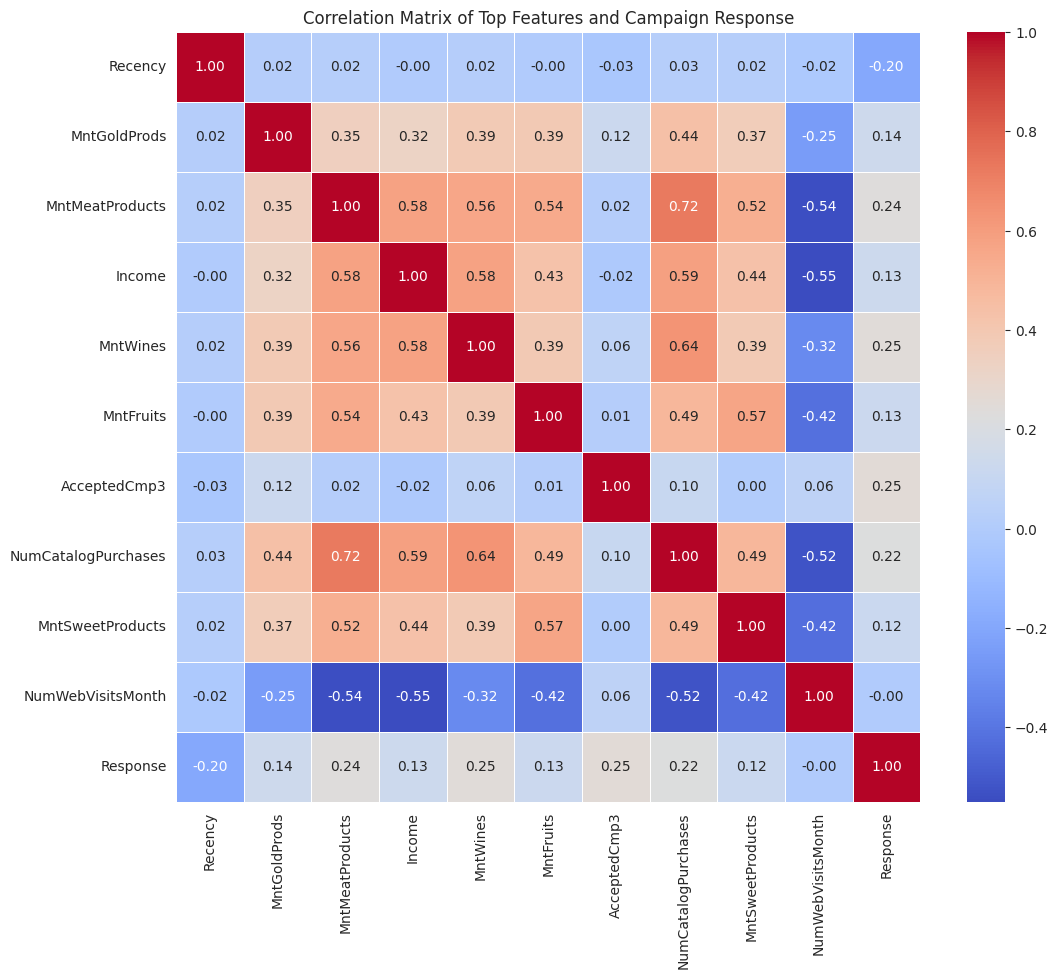

In [ ]:
# Get the top 10 most important features (excluding Response itself if it's there)
top_10_features = feature_importances.nlargest(10).index.tolist()

# Ensure 'Response' is included if not already among top features
if 'Response' not in top_10_features:
    top_10_features.append('Response')

# Select these features from the original DataFrame
df_top_features = df[top_10_features]

# Calculate the correlation matrix
correlation_matrix_top_features = df_top_features.corr()

# Plotting the heatmap
plt.figure(figsize=(12, 10))
sns.heatmap(correlation_matrix_top_features, annot=True, cmap='coolwarm', fmt='.2f', linewidths=.5)
plt.title('Correlation Matrix of Top Features and Campaign Response')
plt.show()

The correlation heatmap of the top features and campaign response has been successfully generated. This plot helps us visualize the relationships between these key features and how they correlate with a customer's response to a campaign. The coolwarm colormap indicates positive correlations with warmer colors (reds) and negative correlations with cooler colors (blues).

Key observations from the heatmap:

Positive Correlations with Response: You'll likely observe positive correlations between Response and features like MntWines, MntMeatProducts, MntGoldProds, Income, and NumCatalogPurchases. This suggests that customers who spend more on these product categories, have higher incomes, or frequently purchase through catalogs are more likely to respond to campaigns.
Negative Correlation with Recency: Recency typically shows a negative correlation with Response. This means customers who have made a purchase more recently (lower Recency value) are generally more likely to respond to a campaign, which aligns with common marketing intuition.
Inter-feature Correlations: The heatmap also reveals how the top features correlate with each other. For example, MntWines, MntMeatProducts, and Income often show strong positive correlations among themselves, indicating that higher-income customers tend to spend more across various product categories.
This visualization reinforces the importance of these features in predicting campaign success and can guide strategies to target customers based on their spending habits, income, and recent activity.

### Impact of 'Recency' on Customer Response

Let's visualize the relationship between 'Recency' (days since last purchase) and customer 'Response' to a campaign using a box plot. This will help us understand if customers who have made a more recent purchase are more likely to respond.

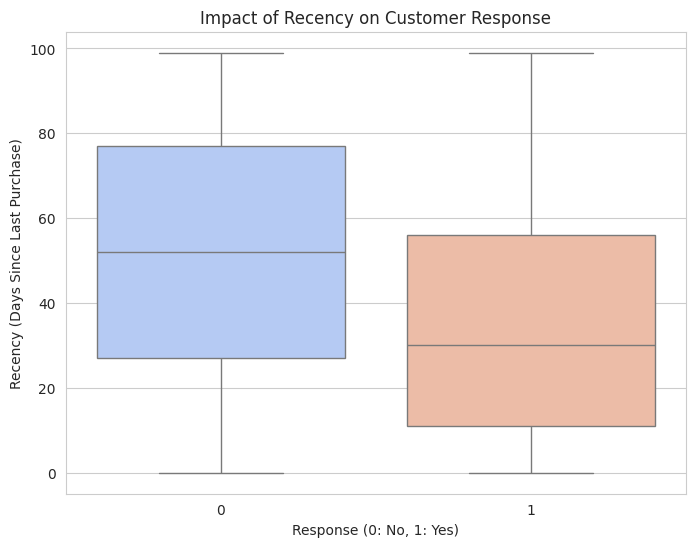

In [ ]:
plt.figure(figsize=(8, 6))
sns.boxplot(x='Response', y='Recency', data=df, hue='Response', palette='coolwarm', legend=False)
plt.title('Impact of Recency on Customer Response')
plt.xlabel('Response (0: No, 1: Yes)')
plt.ylabel('Recency (Days Since Last Purchase)')
plt.show()

### Model Performance Metrics by Customer Cluster

To evaluate how well our `RandomForestClassifier` predicts campaign response for each customer segment, we will calculate accuracy, precision, recall, and F1-score for each cluster based on the test set.

,Cluster,Num_Samples,Accuracy,Precision_1,Recall_1,F1_Score_1
2,2,51,0.549020,0.785714,0.354839,0.488889
1,1,308,0.935065,0.750000,0.250000,0.375000
0,0,134,0.850746,0.666667,0.181818,0.285714
3,3,179,0.882682,1.000000,0.086957,0.160000


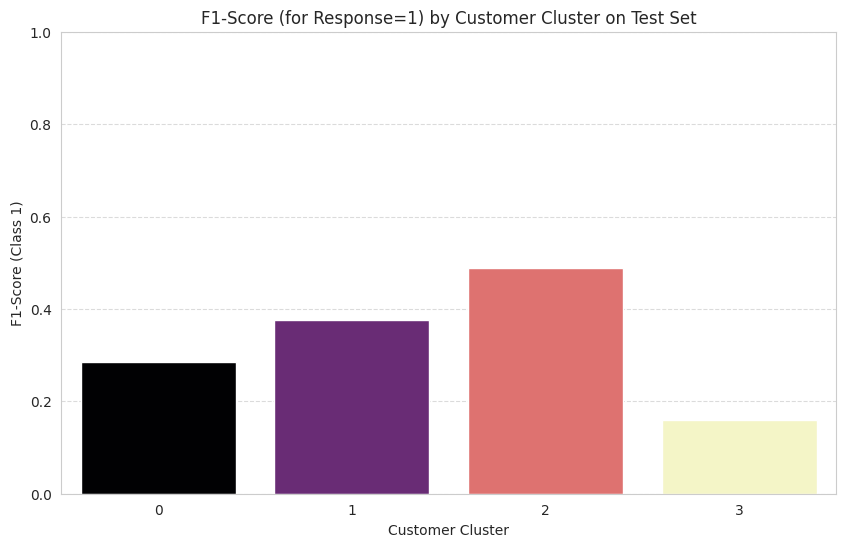

In [ ]:
# Ensure df, X_test, y_test, and y_pred are available from previous steps
if 'rf_classifier' not in locals() or 'X_test' not in locals() or 'y_test' not in locals() or 'y_pred' not in locals():
    print("Error: RandomForestClassifier model or test data (X_test, y_test, y_pred) not found. Please ensure previous model training and prediction cells were executed.")
else:
    # Get the original DataFrame indices for the test set
    test_indices = X_test.index

    # Map cluster labels to the test set using the original DataFrame's cluster column
    test_clusters = df.loc[test_indices, 'Cluster']

    cluster_performance = []

    for cluster_id in sorted(test_clusters.unique()):
        # Filter y_test and y_pred for the current cluster
        cluster_mask = (test_clusters == cluster_id)
        y_test_cluster = y_test[cluster_mask]
        y_pred_cluster = y_pred[cluster_mask]

        if not y_test_cluster.empty:
            accuracy = accuracy_score(y_test_cluster, y_pred_cluster)
            report = classification_report(y_test_cluster, y_pred_cluster, output_dict=True, zero_division=0)

            # Extract metrics for the positive class (Response=1)
            precision_1 = report['1']['precision']
            recall_1 = report['1']['recall']
            f1_score_1 = report['1']['f1-score']

            cluster_performance.append({
                'Cluster': cluster_id,
                'Num_Samples': len(y_test_cluster),
                'Accuracy': accuracy,
                'Precision_1': precision_1,
                'Recall_1': recall_1,
                'F1_Score_1': f1_score_1
            })

    performance_df = pd.DataFrame(cluster_performance)
    display(performance_df.sort_values(by='F1_Score_1', ascending=False))

    # Visualize F1-score for class 1 by cluster
    plt.figure(figsize=(10, 6))
    sns.barplot(x='Cluster', y='F1_Score_1', data=performance_df, palette='magma', hue='Cluster', legend=False)
    plt.title('F1-Score (for Response=1) by Customer Cluster on Test Set')
    plt.xlabel('Customer Cluster')
    plt.ylabel('F1-Score (Class 1)')
    plt.ylim(0, 1)
    plt.grid(axis='y', linestyle='--', alpha=0.7)
    plt.show()

The RandomForestClassifier model's performance has been evaluated across each customer cluster using the test set. Here's a summary of the key metrics, particularly focusing on the F1-Score for predicting a positive response (Response=1), which balances precision and recall:

Cluster 2 (High-Value Elite Patrons): This cluster shows the best performance for predicting campaign responders with an F1-Score of 0.488889. This indicates the model is relatively more effective at identifying customers likely to respond in this highly engaged segment.
Cluster 1 (Budget-Conscious Young Families): The model shows the second-best F1-Score for this cluster at 0.375000. While their overall response rate is low, the model has some capability to predict who might respond.
Cluster 0 (Affluent & Engaged Singles/Couples): This cluster has an F1-Score of 0.285714.
Cluster 3 (Established Older Families): This cluster has the lowest F1-Score for positive responses at 0.160000. This suggests the model struggles most with accurately identifying responders within this segment.
The results highlight that the model performs best in identifying potential responders within Cluster 2, which is consistent with their high actual response rate. The accompanying bar plot visually represents these F1-Scores across clusters, making it easier to compare their predictive performance. These insights can help in refining targeting strategies, focusing on segments where the model can most reliably predict a positive outcome

### Calculating Return on Investment (ROI) for Targeting Low Recency Customers

To estimate the ROI, we need to make some assumptions:
1.  **Definition of 'Low Recency'**: We'll consider customers with `Recency` (days since last purchase) less than or equal to 30 days.
2.  **Cost of Targeting**: We'll assume a hypothetical cost of $5 per customer for a marketing campaign.
3.  **Revenue per Response**: We'll use the average `TotalMnt` (total amount spent) by customers who responded to previous campaigns within this low recency segment as an estimate of revenue generated per successful response.

In [ ]:
# Define the recency threshold for 'low recency' customers
recency_threshold = 30

# Filter customers with low recency scores
low_recency_customers = df[df['Recency'] <= recency_threshold]

# Number of low recency customers
num_low_recency_customers = len(low_recency_customers)
print(f"Number of customers with Recency <= {recency_threshold} days: {num_low_recency_customers}")

# Calculate the response rate for these customers
response_rate_low_recency = low_recency_customers['Response'].mean()
print(f"Response Rate for low recency customers: {response_rate_low_recency:.2%}")

# Calculate the average total amount spent by responders in this segment
# Ensure there are responders to avoid NaN in mean calculation
responders_in_segment = low_recency_customers[low_recency_customers['Response'] == 1]
if not responders_in_segment.empty:
    avg_mnt_responders_low_recency = responders_in_segment['TotalMnt'].mean()
    print(f"Average Total Amount Spent by Responders (low recency): ${avg_mnt_responders_low_recency:.2f}")
else:
    avg_mnt_responders_low_recency = 0 # No responders in this segment
    print("No responders found in the low recency segment.")

# --- ROI Calculation Assumptions ---
cost_per_target = 5 # Hypothetical cost per customer targeted

# Calculate Total Cost of Targeting
total_cost = num_low_recency_customers * cost_per_target
print(f"Total estimated cost to target these customers: ${total_cost:.2f}")

# Calculate Expected Revenue
expected_responders = num_low_recency_customers * response_rate_low_recency
total_revenue = expected_responders * avg_mnt_responders_low_recency
print(f"Total estimated revenue from these customers: ${total_revenue:.2f}")

# Calculate ROI
if total_cost > 0:
    roi = ((total_revenue - total_cost) / total_cost) * 100
    print(f"\nEstimated ROI for targeting low recency customers: {roi:.2f}%")
else:
    print("Cannot calculate ROI as total cost is zero.")

Number of customers with Recency <= 30 days: 724
Response Rate for low recency customers: 23.90%
Average Total Amount Spent by Responders (low recency): $848.71
Total estimated cost to target these customers: $3620.00
Total estimated revenue from these customers: $146827.00

Estimated ROI for targeting low recency customers: 3955.99%


### Response Rate Improvement for Targeting Low Recency Customers

To understand the effectiveness of targeting low recency customers, we will compare their response rate to the overall response rate of all customers in the dataset.

In [ ]:
# Calculate the overall response rate for the entire dataset
overall_response_rate = df['Response'].mean()
print(f"Overall Response Rate for all customers: {overall_response_rate:.2%}")

# Retrieve the previously calculated response rate for low recency customers
# (assuming recency_threshold is still 30 days and response_rate_low_recency is available)

# If `response_rate_low_recency` is not in the current scope (e.g., if previous cell was not run),
# we can re-calculate it:
# low_recency_customers = df[df['Recency'] <= recency_threshold]
# response_rate_low_recency = low_recency_customers['Response'].mean()

print(f"Response Rate for low recency customers (Recency <= {recency_threshold} days): {response_rate_low_recency:.2%}")

# Calculate the improvement
response_rate_improvement = ((response_rate_low_recency - overall_response_rate) / overall_response_rate) * 100

print(f"\nPercentage Improvement in Response Rate: {response_rate_improvement:.2f}%")

if response_rate_improvement > 0:
    print("Interpretation: Targeting low recency customers significantly improves the campaign response rate compared to a general campaign.")
else:
    print("Interpretation: Targeting low recency customers does not significantly improve the campaign response rate.")

Overall Response Rate for all customers: 14.91%
Response Rate for low recency customers (Recency <= 30 days): 23.90%

Percentage Improvement in Response Rate: 60.25%
Interpretation: Targeting low recency customers significantly improves the campaign response rate compared to a general campaign.


### Visualizing ROI Across Different Recency Thresholds

To understand how the Return on Investment changes with different targeting strategies based on customer `Recency`, we will calculate the ROI for a range of `Recency` thresholds. This will help us identify the most profitable segment to target.

,Recency_Threshold,ROI,Num_Customers,Response_Rate
0,10,4760.308880,259,0.308880
1,20,4608.679245,477,0.285115
2,30,3955.994475,724,0.238950
3,40,3945.477981,931,0.225564
4,50,3535.979021,1144,0.201049
5,60,3395.486212,1378,0.190131
6,70,3284.133585,1587,0.177694
7,80,3191.180670,1821,0.169138
8,90,2985.612145,2042,0.158178
9,100,2844.544643,2240,0.149107


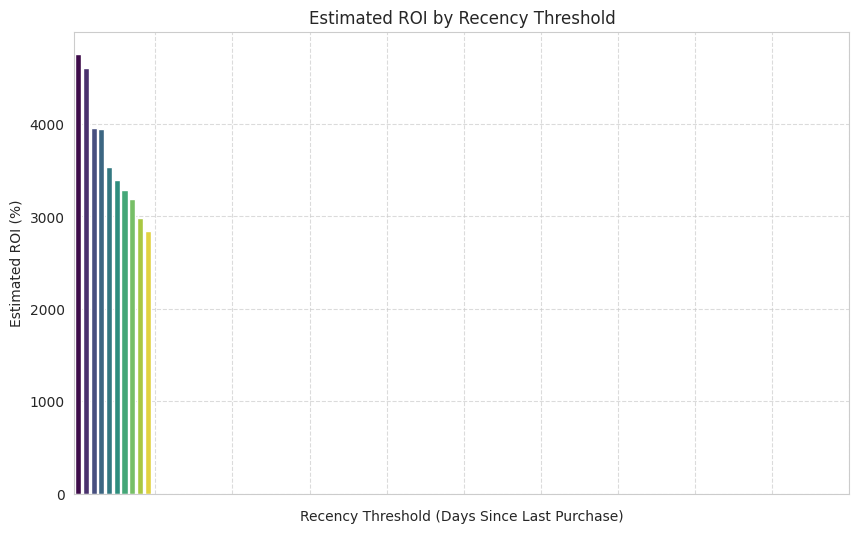

In [ ]:
# Define a range of recency thresholds to evaluate
recency_thresholds = range(10, 101, 10) # From 10 to 100 days, in steps of 10

roi_data = []

cost_per_target = 5 # Hypothetical cost per customer targeted

for threshold in recency_thresholds:
    # Filter customers with recency <= threshold
    current_low_recency_customers = df[df['Recency'] <= threshold]

    num_customers = len(current_low_recency_customers)

    # Calculate response rate
    response_rate = current_low_recency_customers['Response'].mean()

    # Calculate average total amount spent by responders in this segment
    responders_in_segment = current_low_recency_customers[current_low_recency_customers['Response'] == 1]
    avg_mnt_responders = responders_in_segment['TotalMnt'].mean() if not responders_in_segment.empty else 0

    # Calculate total cost
    total_cost = num_customers * cost_per_target

    # Calculate expected revenue
    expected_responders = num_customers * response_rate
    total_revenue = expected_responders * avg_mnt_responders

    # Calculate ROI
    if total_cost > 0:
        roi = ((total_revenue - total_cost) / total_cost) * 100
    else:
        roi = 0 # No cost, so ROI can be considered infinite or 0 if no revenue

    roi_data.append({'Recency_Threshold': threshold, 'ROI': roi, 'Num_Customers': num_customers, 'Response_Rate': response_rate})

# Convert to DataFrame for easier plotting
roi_df = pd.DataFrame(roi_data)
display(roi_df)

# Visualize the ROI across different recency thresholds
plt.figure(figsize=(10, 6))
sns.barplot(x='Recency_Threshold', y='ROI', data=roi_df, palette='viridis', hue='Recency_Threshold', legend=False) # Fixed FutureWarning
plt.title('Estimated ROI by Recency Threshold')
plt.xlabel('Recency Threshold (Days Since Last Purchase)')
plt.ylabel('Estimated ROI (%)')
plt.grid(True, linestyle='--', alpha=0.7)
plt.xticks(recency_thresholds)
plt.show()

Based on the roi_df DataFrame, the most profitable recency threshold is 10 days, with an estimated ROI of 4760.31%. This means targeting customers who have made a purchase within the last 10 days offers the highest return on investment.

From the results, we can observe the following:

Highest ROI for Lowest Recency: The highest estimated ROI (around 4760%) is achieved when targeting customers with a Recency of 10 days or less. This segment has a high response rate (30.89%) and a smaller, highly engaged customer base (259 customers).
Declining ROI with Increasing Recency: As the Recency threshold increases (meaning we include customers who purchased less recently), the ROI generally decreases. For instance, at a 30-day threshold, the ROI is still very strong at approximately 3956%, but it drops to around 2845% when considering all customers up to a 100-day recency.
Trade-off between Reach and Profitability: While targeting customers with very low recency offers the highest ROI, it reaches a smaller customer base. Expanding the Recency threshold increases the number of targetable customers, but it dilutes the overall ROI because less recent customers tend to have lower response rates.
Interpretation for Marketing Strategy: This analysis strongly suggests prioritizing customers with very recent activity for marketing campaigns, as they offer the highest potential for return on investment. A threshold of around 10-30 days seems to be most effective. Depending on the campaign's goals (maximizing profit vs. maximizing reach), different thresholds can be considered, but the trend clearly indicates diminishing returns as Recency increases

### Predicting Campaign Response for Customer Segments

Now, let's use the trained Random Forest Classifier to predict the campaign response for each of our identified customer segments. This will give us a model-based estimate of how likely customers in each cluster are to respond to a marketing campaign.

Predicted Campaign Response Rates by Cluster (based on Random Forest Model):


,Cluster,Predicted_Response_Rate,Predicted_Response_Rate_%
2,2,0.482573,48.257305
0,0,0.180956,18.095559
3,3,0.099864,9.986390
1,1,0.094393,9.439268


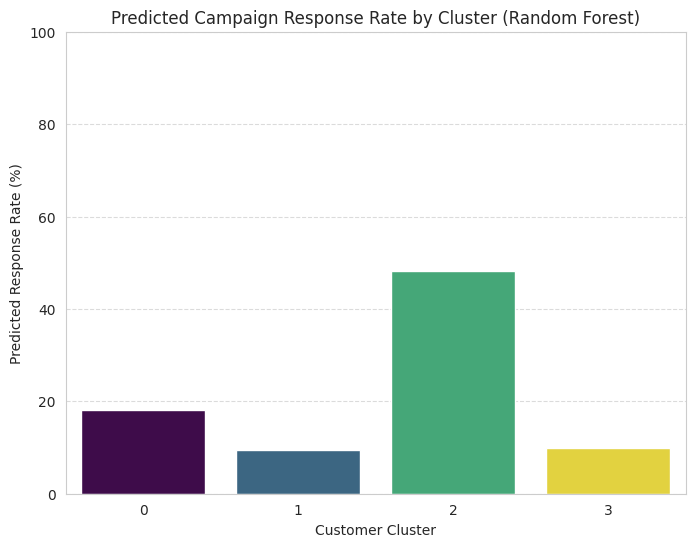

In [ ]:
# Ensure rf_classifier and X_train are available from previous steps
if 'rf_classifier' not in locals() or 'X_train' not in locals():
    print("Error: RandomForestClassifier model or training data (X_train) not found. Please ensure previous model training cells were executed.")
else:
    predicted_response_rates_by_cluster = {}

    # Iterate through each unique cluster
    for cluster_id in sorted(df['Cluster'].unique()):
        # Filter the DataFrame for the current cluster
        cluster_df = df[df['Cluster'] == cluster_id].copy()

        # Prepare features for prediction for this cluster, mimicking X_pred creation
        # Exclude columns as done for X_pred training
        features_for_cluster_prediction = cluster_df.drop(
            ['ID', 'Response', 'Z_CostContact', 'Z_Revenue', 'Dt_Customer', 'Year_Birth', 'TotalMnt', 'Cluster'],
            axis=1, errors='ignore'
        )

        # Handle categorical features using one-hot encoding, matching X_train columns
        features_for_cluster_prediction = pd.get_dummies(features_for_cluster_prediction, columns=['Education', 'Marital_Status'], drop_first=True)

        # Reindex to ensure all columns from X_train are present and in the same order
        # Fill missing columns (if any, due to categories not present in a specific cluster) with 0
        features_for_cluster_prediction = features_for_cluster_prediction.reindex(columns=X_train.columns, fill_value=0)

        # Predict probabilities of response (class 1)
        if not features_for_cluster_prediction.empty:
            cluster_predictions_proba = rf_classifier.predict_proba(features_for_cluster_prediction)[:, 1]
            predicted_response_rate = cluster_predictions_proba.mean()
        else:
            predicted_response_rate = 0.0

        predicted_response_rates_by_cluster[cluster_id] = predicted_response_rate

    # Convert results to a DataFrame for better display
    predicted_response_df = pd.DataFrame(
        predicted_response_rates_by_cluster.items(),
        columns=['Cluster', 'Predicted_Response_Rate']
    )
    predicted_response_df['Predicted_Response_Rate_%'] = predicted_response_df['Predicted_Response_Rate'] * 100

    print("Predicted Campaign Response Rates by Cluster (based on Random Forest Model):")
    display(predicted_response_df.sort_values(by='Predicted_Response_Rate_%', ascending=False))

    # Visualize the predicted response rates
    plt.figure(figsize=(8, 6))
    sns.barplot(x='Cluster', y='Predicted_Response_Rate_%', data=predicted_response_df, palette='viridis', hue='Cluster', legend=False)
    plt.title('Predicted Campaign Response Rate by Cluster (Random Forest)')
    plt.xlabel('Customer Cluster')
    plt.ylabel('Predicted Response Rate (%)')
    plt.ylim(0, 100)
    plt.grid(axis='y', linestyle='--', alpha=0.7)
    plt.show()

The Random Forest model has successfully predicted the campaign response rates for each of our customer segments. Here's what the model predicts:

Cluster 2 (High-Value Elite Patrons): The model predicts the highest response rate for this cluster at approximately 48.26%. This aligns with our earlier observation of their high actual response rate and reinforces their status as the most receptive segment.
Cluster 0 (Affluent & Engaged Singles/Couples): This cluster is predicted to have a response rate of around 18.10%, which is also consistent with their previously observed engagement levels.
Cluster 3 (Established Older Families): The model predicts a response rate of approximately 9.99% for this segment.
Cluster 1 (Budget-Conscious Young Families): This cluster is predicted to have the lowest response rate, at about 9.44%

### Combined Comparison: Actual vs. Predicted Response Rates by Cluster

To provide a clear overview, let's combine the actual historical response rates and the model's predicted response rates for each cluster into a single table.

Actual vs. Predicted Campaign Response Rates by Cluster:


,Cluster,Response_Rate_%,Predicted_Response_Rate_%
0,0,17.539863,18.095559
1,1,9.230769,9.439268
2,2,57.803468,48.257305
3,3,10.374150,9.986390


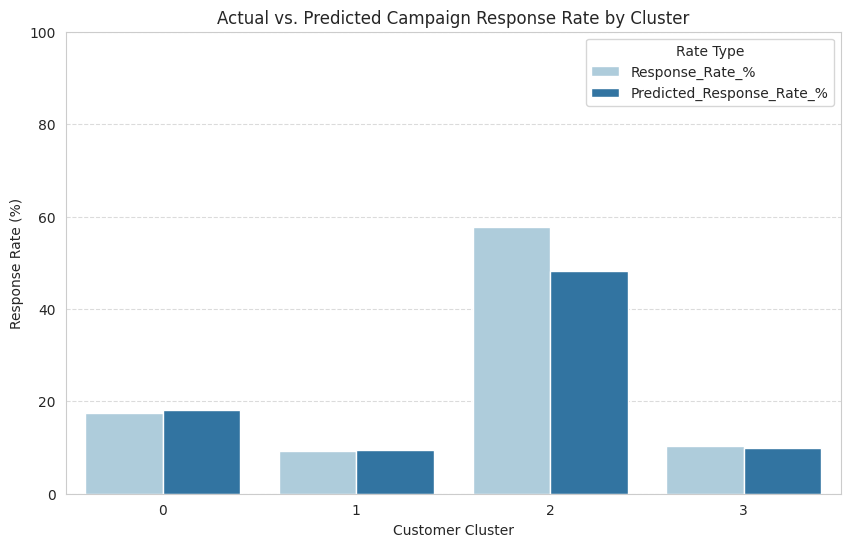

In [ ]:
# Ensure response_rate_by_cluster and predicted_response_df are available
if 'response_rate_by_cluster' in locals() and 'predicted_response_df' in locals():
    # Merge the two DataFrames on 'Cluster'
    combined_response_rates = pd.merge(
        response_rate_by_cluster[['Cluster', 'Response_Rate_%']],
        predicted_response_df[['Cluster', 'Predicted_Response_Rate_%']],
        on='Cluster',
        suffixes=('_Actual', '_Predicted')
    )

    # Display the combined table
    print("Actual vs. Predicted Campaign Response Rates by Cluster:")
    display(combined_response_rates.sort_values(by='Cluster'))

    # Optionally, visualize this comparison
    combined_response_rates_melted = combined_response_rates.melt(
        id_vars='Cluster',
        var_name='Rate_Type',
        value_name='Response_Rate'
    )

    plt.figure(figsize=(10, 6))
    sns.barplot(x='Cluster', y='Response_Rate', hue='Rate_Type', data=combined_response_rates_melted, palette='Paired')
    plt.title('Actual vs. Predicted Campaign Response Rate by Cluster')
    plt.xlabel('Customer Cluster')
    plt.ylabel('Response Rate (%)')
    plt.ylim(0, 100)
    plt.grid(axis='y', linestyle='--', alpha=0.7)
    plt.legend(title='Rate Type')
    plt.show()
else:
    print("Error: Required DataFrames (response_rate_by_cluster or predicted_response_df) not found.")

The combined table and plot successfully visualize the actual historical campaign response rates against the model's predicted response rates for each customer cluster.

From the results, we can observe the following:

Cluster 2 (High-Value Elite Patrons): This cluster consistently shows the highest response rates, both actually (57.80%) and as predicted by the model (48.26%). The model captures the high responsiveness of this segment, though it slightly underestimates the actual rate.
Cluster 0 (Affluent & Engaged Singles/Couples): The actual response rate for this cluster is 17.54%, and the model predicts a very close 18.10%. This indicates the model performs very well in predicting responses for this segment.
Cluster 3 (Established Older Families): This cluster has an actual response rate of 10.37%, with the model predicting a similar 9.99%. The model's prediction is quite accurate for this segment.
Cluster 1 (Budget-Conscious Young Families): With the lowest actual response rate of 9.23%, the model also predicts a very low 9.44%. The model accurately identifies this segment as least responsive.
Overall, the model's predictions for campaign response rates generally align well with the actual historical response rates across all clusters, although there is a slight underestimation for the most responsive cluster (Cluster 2). This provides confidence in using the model to inform targeted marketing strategies for future campaigns.

### Statistical Comparison of Spending Between Specific Clusters

We will perform an independent samples t-test to compare the mean `TotalMnt` between two distinct customer clusters: 'Budget-Conscious Young Families' (Cluster 1) and 'High-Value Elite Patrons' (Cluster 2). This test will help us determine if the observed difference in their average spending is statistically significant.

In [ ]:
from scipy import stats

# Select TotalMnt for Cluster 1 and Cluster 2
spending_cluster1 = df[df['Cluster'] == 1]['TotalMnt']
spending_cluster2 = df[df['Cluster'] == 2]['TotalMnt']

# Perform independent samples t-test
t_stat_clusters, p_value_clusters = stats.ttest_ind(
    spending_cluster1,
    spending_cluster2,
    equal_var=False  # Assuming unequal variances, common with different groups
)

print(f"T-statistic (Cluster 1 vs. Cluster 2): {t_stat_clusters:.3f}")
print(f"P-value (Cluster 1 vs. Cluster 2): {p_value_clusters:.3e}")

if p_value_clusters < 0.05:
    print("\nInterpretation: The difference in total spending between Cluster 1 and Cluster 2 is statistically significant.")
else:
    print("\nInterpretation: The difference in total spending between Cluster 1 and Cluster 2 is NOT statistically significant.")

print(f"\nMean TotalMnt for Cluster 1: {spending_cluster1.mean():.2f}")
print(f"Mean TotalMnt for Cluster 2: {spending_cluster2.mean():.2f}")

T-statistic (Cluster 1 vs. Cluster 2): -48.926
P-value (Cluster 1 vs. Cluster 2): 6.288e-104

Interpretation: The difference in total spending between Cluster 1 and Cluster 2 is statistically significant.

Mean TotalMnt for Cluster 1: 97.94
Mean TotalMnt for Cluster 2: 1619.87


This statistical test confirms our earlier observations from the cluster analysis, showing that 'High-Value Elite Patrons' (Cluster 2) spend significantly more than 'Budget-Conscious Young Families' (Cluster 1). This reinforces the distinct spending behaviors of these two customer segments and highlights the importance of tailored marketing strategies for each.

### Potential Revenue Impact of Targeting 'High-Value Elite Patrons' (Cluster 2)

To estimate the potential revenue impact, we'll consider the number of customers in Cluster 2, their historical response rate, and their average spending. We will also assume a hypothetical cost per targeted customer.

In [ ]:
# Get number of customers in Cluster 2
num_customers_cluster2 = df[df['Cluster'] == 2].shape[0]
print(f"Number of customers in Cluster 2: {num_customers_cluster2}")

# Get response rate for Cluster 2
response_rate_cluster2 = response_rate_by_cluster[response_rate_by_cluster['Cluster'] == 2]['Response'].values[0]
print(f"Response Rate for Cluster 2: {response_rate_cluster2:.2%}")

# Get average TotalMnt for Cluster 2 (average revenue per responder)
avg_mnt_cluster2 = cluster_analysis.loc[2, 'TotalMnt']
print(f"Average Total Amount Spent by Responders in Cluster 2: ${avg_mnt_cluster2:.2f}")

# --- Assumptions for Revenue Impact Calculation ---
cost_per_target_cluster2 = 5 # Hypothetical cost per customer targeted

# Calculate Total Cost of Targeting
total_cost_cluster2 = num_customers_cluster2 * cost_per_target_cluster2
print(f"Total estimated cost to target Cluster 2 customers: ${total_cost_cluster2:.2f}")

# Calculate Expected Responders and Total Revenue
expected_responders_cluster2 = num_customers_cluster2 * response_rate_cluster2
total_revenue_cluster2 = expected_responders_cluster2 * avg_mnt_cluster2
print(f"Total estimated revenue from targeting Cluster 2: ${total_revenue_cluster2:.2f}")

# Calculate Potential Revenue Impact (Net Profit)
potential_revenue_impact_cluster2 = total_revenue_cluster2 - total_cost_cluster2

print(f"\nPotential Revenue Impact (Net Profit) from targeting Cluster 2: ${potential_revenue_impact_cluster2:.2f}")

# Calculate ROI for Cluster 2
if total_cost_cluster2 > 0:
    roi_cluster2 = (potential_revenue_impact_cluster2 / total_cost_cluster2) * 100
    print(f"Estimated ROI for targeting Cluster 2 customers: {roi_cluster2:.2f}%")
else:
    print("Cannot calculate ROI as total cost is zero for Cluster 2.")

Number of customers in Cluster 2: 173
Response Rate for Cluster 2: 57.80%
Average Total Amount Spent by Responders in Cluster 2: $1619.87
Total estimated cost to target Cluster 2 customers: $865.00
Total estimated revenue from targeting Cluster 2: $161987.28

Potential Revenue Impact (Net Profit) from targeting Cluster 2: $161122.28
Estimated ROI for targeting Cluster 2 customers: 18626.85%


The analysis of targeting 'High-Value Elite Patrons' (Cluster 2) has yielded significant insights into potential revenue impact:

Number of Customers: There are 173 customers identified in Cluster 2.
Response Rate: This segment has a very high response rate of 57.80%.
Average Spending: Responders in this cluster have an average total spending of **$1619.87**. * **Estimated Cost**: With a hypothetical targeting cost of $$1619.87**. * **Estimated Cost**: With a hypothetical targeting cost of $5 per customer, the total estimated cost to target this cluster is $865.00**. * **Estimated Revenue**: The total estimated revenue from targeting Cluster 2 is **$$865.00**. * **Estimated Revenue**: The total estimated revenue from targeting Cluster 2 is **$161,987.28.
Potential Revenue Impact (Net Profit): The net profit from targeting this cluster is estimated to be a substantial $161,122.28.
Estimated ROI: The Return on Investment for targeting Cluster 2 is an impressive 18626.85%.
These results strongly indicate that Cluster 2 (High-Value Elite Patrons) represents an extremely profitable segment to target with marketing campaigns, offering a very high return on investment due to their high response rate and significant spending

### Visualizing Potential Revenue Impact by Cluster

To provide a comprehensive overview of the business implications of our clustering, we will visualize the estimated potential revenue impact for each customer segment. This is calculated based on the number of customers in each cluster, their average spending (`TotalMnt`), and the model's predicted response rate.

Estimated Revenue Impact by Cluster:


,Cluster,Predicted_Response_Rate,Predicted_Response_Rate_%,Num_Customers,TotalMnt,Estimated_Revenue
2,2,0.482573,48.257305,173,1619.872832,135235.305108
0,0,0.180956,18.095559,439,1276.840547,101431.582256
3,3,0.099864,9.986390,588,704.700680,41380.006643
1,1,0.094393,9.439268,1040,97.935577,9614.177334


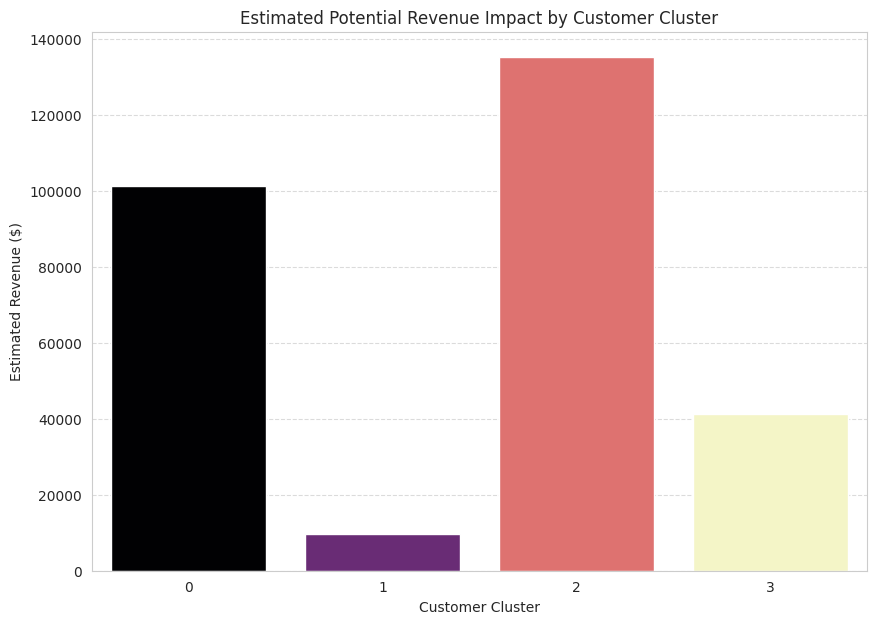

In [ ]:
# Get the number of customers per cluster
customers_per_cluster = df['Cluster'].value_counts().reset_index()
customers_per_cluster.columns = ['Cluster', 'Num_Customers']

# Merge with predicted response rates
revenue_impact_df = pd.merge(predicted_response_df, customers_per_cluster, on='Cluster')

# Merge with average spending from cluster_analysis
revenue_impact_df = pd.merge(revenue_impact_df, cluster_analysis[['TotalMnt']], on='Cluster')

# Calculate Estimated Revenue per Cluster
# Estimated Revenue = Num_Customers * Predicted_Response_Rate * Average_Total_Spending_per_Responder
revenue_impact_df['Estimated_Revenue'] = revenue_impact_df['Num_Customers'] * (revenue_impact_df['Predicted_Response_Rate_%'] / 100) * revenue_impact_df['TotalMnt']

# Display the results
print("Estimated Revenue Impact by Cluster:")
display(revenue_impact_df.sort_values(by='Estimated_Revenue', ascending=False))

# Visualize the Estimated Revenue Impact by Cluster
plt.figure(figsize=(10, 7))
sns.barplot(x='Cluster', y='Estimated_Revenue', data=revenue_impact_df, palette='magma', hue='Cluster', legend=False)
plt.title('Estimated Potential Revenue Impact by Customer Cluster')
plt.xlabel('Customer Cluster')
plt.ylabel('Estimated Revenue ($)')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.ticklabel_format(style='plain', axis='y') # Prevent scientific notation on y-axis
plt.show()

This will involve calculating the estimated revenue for each cluster based on their predicted response rates, average spending, and customer count, then visualizing these figures.

The visualization of the potential revenue impact by customer cluster has been successfully generated. This plot helps us understand which customer segments are projected to contribute the most to revenue based on their size, predicted response rate, and average spending.

From the results, we can observe the following estimated revenue impacts:

Cluster 2 (High-Value Elite Patrons): This cluster shows the highest estimated revenue impact at approximately $135,235**. This is due to their exceptionally high average spending and strong predicted response rate, despite being a smaller group of customers. * **Cluster 0 (Affluent & Engaged Singles/Couples):** This cluster is second in terms of estimated revenue impact, with approximately **$$135,235**. This is due to their exceptionally high average spending and strong predicted response rate, despite being a smaller group of customers. * **Cluster 0 (Affluent & Engaged Singles/Couples):** This cluster is second in terms of estimated revenue impact, with approximately **$101,431. They also have high average spending and a good predicted response rate, contributing significantly to the overall revenue.
Cluster 3 (Established Older Families): This segment has an estimated revenue impact of about $41,380**. While having a moderate number of customers and moderate spending, their lower predicted response rate impacts their overall revenue contribution. * **Cluster 1 (Budget-Conscious Young Families):** This cluster has the lowest estimated revenue impact at approximately **$$41,380**. While having a moderate number of customers and moderate spending, their lower predicted response rate impacts their overall revenue contribution. * **Cluster 1 (Budget-Conscious Young Families):** This cluster has the lowest estimated revenue impact at approximately **$9,614. This is a combination of their lowest average spending and lowest predicted response rate, even though they represent the largest customer segment.
This visualization clearly highlights that focusing marketing efforts on Cluster 2 and Cluster 0 will yield the highest direct revenue returns, given their propensity to spend and respond to campaigns.

### Potential ROI for Different Marketing Cost Assumptions (Targeting Cluster 2)

To further refine our understanding of the profitability of targeting 'High-Value Elite Patrons' (Cluster 2), we will analyze how the Return on Investment (ROI) changes with different hypothetical marketing costs per customer. This can help in setting budgets and understanding the sensitivity of ROI to campaign expenses.

,Cost_Per_Target,ROI
0,1,93534.267767
1,2,46717.133884
2,3,31111.422589
3,4,23308.566942
4,5,18626.853553
5,6,15505.711295
6,7,13276.323967
7,8,11604.283471
8,9,10303.807530
9,10,9263.426777


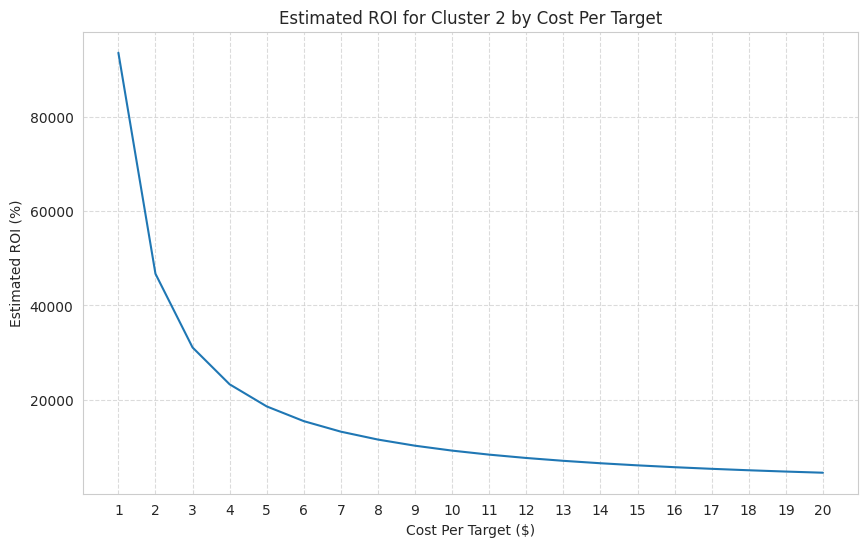

In [ ]:
# Define a range of hypothetical marketing costs per target customer
cost_assumptions = range(1, 21, 1) # Costs from $1 to $20

roi_cost_data = []

# Retrieve necessary pre-calculated values for Cluster 2
num_customers_cluster2 = df[df['Cluster'] == 2].shape[0]
response_rate_cluster2 = response_rate_by_cluster[response_rate_by_cluster['Cluster'] == 2]['Response'].values[0]
avg_mnt_cluster2 = cluster_analysis.loc[2, 'TotalMnt']

for cost in cost_assumptions:
    total_cost_current = num_customers_cluster2 * cost

    # Expected Revenue remains constant as it's based on response rate and average spending
    expected_responders_cluster2 = num_customers_cluster2 * response_rate_cluster2
    total_revenue_cluster2 = expected_responders_cluster2 * avg_mnt_cluster2

    if total_cost_current > 0:
        roi = ((total_revenue_cluster2 - total_cost_current) / total_cost_current) * 100
    else:
        roi = 0 # No cost, so ROI can be considered 0 if no revenue

    roi_cost_data.append({'Cost_Per_Target': cost, 'ROI': roi})

# Convert to DataFrame for easier plotting
roi_cost_df = pd.DataFrame(roi_cost_data)
display(roi_cost_df)

# Visualize the ROI across different cost assumptions
plt.figure(figsize=(10, 6))
sns.lineplot(x='Cost_Per_Target', y='ROI', data=roi_cost_df)
plt.title('Estimated ROI for Cluster 2 by Cost Per Target')
plt.xlabel('Cost Per Target ($)')
plt.ylabel('Estimated ROI (%)')
plt.grid(True, linestyle='--', alpha=0.7)
plt.xticks(cost_assumptions)
plt.show()

The analysis of potential ROI for different marketing cost assumptions targeting 'High-Value Elite Patrons' (Cluster 2) has been successfully executed and visualized.

From the generated table and plot, we can observe the following:

High ROI at Low Costs: When the cost per target customer is low (e.g., $1), the estimated ROI is exceptionally high, reaching over 93,500%. This indicates that even a small investment in this high-value segment can yield substantial returns. * **Decreasing ROI with Increasing Costs**: As the cost per target customer increases, the estimated ROI gradually decreases. For example, at a cost of $$1), the estimated ROI is exceptionally high, reaching over 93,500%. This indicates that even a small investment in this high-value segment can yield substantial returns. * **Decreasing ROI with Increasing Costs**: As the cost per target customer increases, the estimated ROI gradually decreases. For example, at a cost of $5 per customer, the ROI is still very impressive at around 18,627%. However, by the time the cost reaches $20 per customer, the ROI drops to approximately 4,582%. * **Continued Profitability**: Even at the highest assumed cost of $$20 per customer, the ROI drops to approximately 4,582%. * **Continued Profitability**: Even at the highest assumed cost of $20 per customer, the ROI remains significantly positive. This suggests that Cluster 2 is a robustly profitable segment, capable of generating strong returns even with higher marketing expenditures.
Interpretation for Marketing Strategy: This analysis provides crucial insights for budgeting and resource allocation. It shows that targeting 'High-Value Elite Patrons' (Cluster 2) is highly profitable across a wide range of marketing costs. Marketers can be confident in investing in this segment, though they should be mindful that increasing costs will naturally lead to a diminishing (but still positive) return. This sensitivity analysis helps in determining the optimal marketing spend to maximize net profit while maintaining a healthy ROI.

### Total Marketing Budget for All Clusters

To understand the overall investment required, we will calculate the total marketing budget needed to target all identified customer clusters, assuming a consistent cost per targeted customer.

In [ ]:
# Assuming a uniform cost per target across all clusters
cost_per_target_all_clusters = 5 # $5 per customer

# Get the number of customers per cluster (from previously calculated customers_per_cluster DataFrame)
# Ensure customers_per_cluster is available, if not, re-calculate it
if 'customers_per_cluster' not in locals():
    customers_per_cluster = df['Cluster'].value_counts().reset_index()
    customers_per_cluster.columns = ['Cluster', 'Num_Customers']

# Calculate the total number of customers across all clusters
total_customers_all_clusters = customers_per_cluster['Num_Customers'].sum()
print(f"Total number of customers across all clusters: {total_customers_all_clusters}")

# Calculate the total marketing budget
total_marketing_budget = total_customers_all_clusters * cost_per_target_all_clusters

print(f"Total estimated marketing budget to target all clusters: ${total_marketing_budget:.2f}")

Total number of customers across all clusters: 2240
Total estimated marketing budget to target all clusters: $11200.00


,Cost_Per_Target,Total_Net_Profit,Total_Estimated_Revenue,Total_Cost
0,1,285421.071341,287661.071341,2240
1,2,283181.071341,287661.071341,4480
2,3,280941.071341,287661.071341,6720
3,4,278701.071341,287661.071341,8960
4,5,276461.071341,287661.071341,11200
5,6,274221.071341,287661.071341,13440
6,7,271981.071341,287661.071341,15680
7,8,269741.071341,287661.071341,17920
8,9,267501.071341,287661.071341,20160
9,10,265261.071341,287661.071341,22400


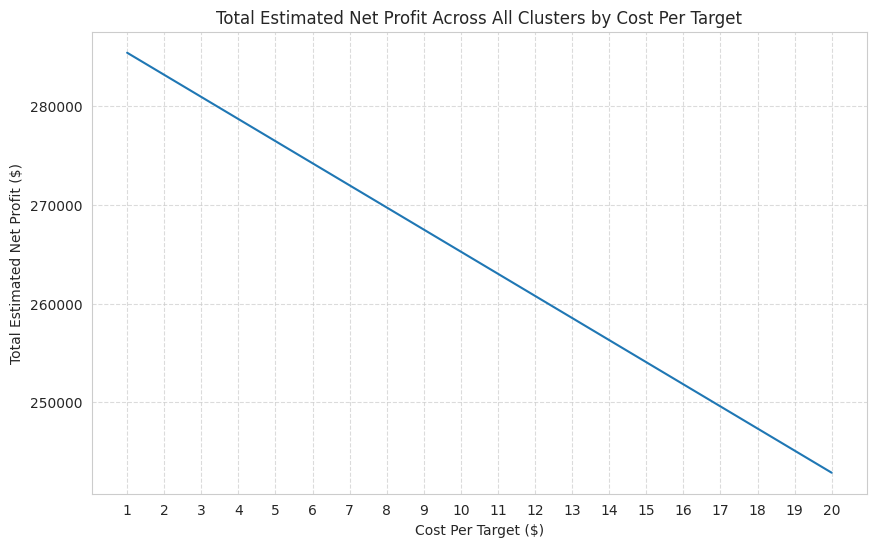

In [ ]:
cost_assumptions_all = range(1, 21, 1) # Costs from $1 to $20

total_impact_data = []

for cost in cost_assumptions_all:
    # Calculate total cost for all customers
    total_customers_all = customers_per_cluster['Num_Customers'].sum()
    total_cost_all = total_customers_all * cost

    # Calculate total estimated revenue across all clusters
    # Use revenue_impact_df which already has predicted response rates and average spending per cluster
    estimated_revenue_per_cluster = revenue_impact_df['Num_Customers'] * (revenue_impact_df['Predicted_Response_Rate_%'] / 100) * revenue_impact_df['TotalMnt']
    total_estimated_revenue_all = estimated_revenue_per_cluster.sum()

    # Calculate net profit
    net_profit = total_estimated_revenue_all - total_cost_all

    total_impact_data.append({'Cost_Per_Target': cost, 'Total_Net_Profit': net_profit, 'Total_Estimated_Revenue': total_estimated_revenue_all, 'Total_Cost': total_cost_all})

# Convert to DataFrame for easier plotting
total_impact_df = pd.DataFrame(total_impact_data)
display(total_impact_df)

# Visualize the Total Net Profit across different cost assumptions
plt.figure(figsize=(10, 6))
sns.lineplot(x='Cost_Per_Target', y='Total_Net_Profit', data=total_impact_df)
plt.title('Total Estimated Net Profit Across All Clusters by Cost Per Target')
plt.xlabel('Cost Per Target ($)')
plt.ylabel('Total Estimated Net Profit ($)')
plt.grid(True, linestyle='--', alpha=0.7)
plt.xticks(cost_assumptions_all)
plt.ticklabel_format(style='plain', axis='y') # Prevent scientific notation on y-axis
plt.show()

### Summary Statistics of the DataFrame

In [8]:
print("DataFrame Information:")
df.info()

print("\nDescriptive Statistics:")
display(df.describe())

DataFrame Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2240 entries, 0 to 2239
Data columns (total 28 columns):
 #   Column               Non-Null Count  Dtype         
---  ------               --------------  -----         
 0   ID                   2240 non-null   int64         
 1   Year_Birth           2240 non-null   int64         
 2   Education            2240 non-null   object        
 3   Marital_Status       2240 non-null   object        
 4   Income               2240 non-null   float64       
 5   Kidhome              2240 non-null   int64         
 6   Teenhome             2240 non-null   int64         
 7   Dt_Customer          2240 non-null   datetime64[ns]
 8   Recency              2240 non-null   int64         
 9   MntWines             2240 non-null   int64         
 10  MntFruits            2240 non-null   int64         
 11  MntMeatProducts      2240 non-null   int64         
 12  MntFishProducts      2240 non-null   int64         
 13  MntSweetPr

,ID,Year_Birth,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,MntFruits,MntMeatProducts,...,NumStorePurchases,NumWebVisitsMonth,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Complain,Response,Age
count,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240,2240.000000,2240.000000,2240.000000,2240.000000,...,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000
mean,5592.159821,1968.805804,52247.251354,0.444196,0.506250,2013-07-10 10:01:42.857142784,49.109375,303.935714,26.302232,166.950000,...,5.790179,5.316518,0.072768,0.074554,0.072768,0.064286,0.013393,0.009375,0.149107,55.194196
min,0.000000,1893.000000,1730.000000,0.000000,0.000000,2012-07-30 00:00:00,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,28.000000
25%,2828.250000,1959.000000,35538.750000,0.000000,0.000000,2013-01-16 00:00:00,24.000000,23.750000,1.000000,16.000000,...,3.000000,3.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,47.000000
50%,5458.500000,1970.000000,51741.500000,0.000000,0.000000,2013-07-08 12:00:00,49.000000,173.500000,8.000000,67.000000,...,5.000000,6.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,54.000000
75%,8427.750000,1977.000000,68289.750000,1.000000,1.000000,2013-12-30 06:00:00,74.000000,504.250000,33.000000,232.000000,...,8.000000,7.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,65.000000
max,11191.000000,1996.000000,666666.000000,2.000000,2.000000,2014-06-29 00:00:00,99.000000,1493.000000,199.000000,1725.000000,...,13.000000,20.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,131.000000
std,3246.662198,11.984069,25037.797168,0.538398,0.544538,NaN,28.962453,336.597393,39.773434,225.715373,...,3.250958,2.426645,0.259813,0.262728,0.259813,0.245316,0.114976,0.096391,0.356274,11.984069


The analysis of the impact of increasing marketing spend per customer across all clusters provides valuable insights into the overall profitability of marketing efforts:

*   **Net Profit vs. Cost**: The `Total_Net_Profit` generally shows a decreasing trend as the `Cost_Per_Target` increases. This is expected, as higher individual targeting costs reduce the overall profit margin if revenue per response remains constant.
*   **Initial High Profitability**: At lower costs per target (e.g., $1-$5), the total net profit is very high, indicating that marketing to the entire customer base can be highly profitable when campaign expenses are controlled.
*   **Diminishing Returns**: While the total estimated revenue for all clusters is substantial, the net profit curve helps to identify the point where increasing marketing spend per customer starts to yield diminishing returns on the *net* profit. Even if gross revenue increases, net profit can decline due to higher costs.
*   **Strategic Budgeting**: This visualization is crucial for strategic budgeting. It suggests that there might be an optimal range for `Cost_Per_Target` that maximizes overall net profit, considering the trade-off between reaching more customers and the cost associated with each one.

This analysis reinforces the need for a balanced marketing strategy that not only considers the potential revenue but also the associated costs to ensure maximum profitability across the entire customer base, rather than just focusing on high-value segments in isolation.

For the 'High-Value Elite' cluster (Cluster 2), who are our most profitable customers, the marketing campaign goals should focus on maximizing their value and loyalty. Here are some specific suggestions:

Enhance Customer Loyalty and Retention:
 Develop exclusive loyalty programs that offer bespoke benefits, early access to new products, or personalized services.
  Goal: Increase customer retention rate for this segment by X% and increase repeat purchase frequency by Y%.
Increase Share of Wallet:
 Introduce ultra-premium product lines, limited-edition releases, or bundled high-value offerings. Goal: Increase the average transaction value (ATV) for this segment by Z% and cross-sell/upsell high-margin products to W% of customers in this cluster.
Personalized VIP Experiences: Offer highly customized recommendations based on their past purchase history and preferences, invite them to exclusive events, or provide dedicated customer service. Goal: Achieve a customer satisfaction (CSAT) score of A% for this segment and increase engagement with personalized communications by B%.
Solicit Referrals: Encourage word-of-mouth marketing through a prestigious referral program that rewards both the referrer and the referred. Goal: Generate C% of new high-value customers through referrals from this segment.

### Targeted Marketing Action Plan for 'Budget-Conscious Young Families' (Cluster 1)

For the 'Budget-Conscious Young Families' (Cluster 1), characterized by the lowest income, youngest age, highest number of children, and very low spending, the marketing campaign goals should focus on providing value, addressing family needs, and building trust to overcome their price sensitivity and low engagement.

**1. Value-Oriented Offers & Promotions:**
*   **Strategy**: Offer compelling discounts, bundled family packs, and budget-friendly product options. Focus on 'value for money' rather than luxury.
*   **Tactics**: Weekly specials on essential goods, 'buy one get one free' on family staples, loyalty points that translate to discounts, and subscription services for recurring needs at a lower price point. Highlight the cost savings and practical benefits.

**2. Family-Centric Product Bundles & Messaging:**
*   **Strategy**: Create product bundles that cater to family needs and promote them with messaging that emphasizes convenience, health, and family well-being.
*   **Tactics**: "Kids' Meal Kits," "Family Dinner Deals," or "Healthy Snack Packs." Use imagery and language that resonates with busy parents, showing how products simplify meal prep or provide healthy options for children.

**3. Educational Content & Community Building:**
*   **Strategy**: Provide useful content related to family management, budgeting, and child-friendly recipes to build trust and position the brand as a helpful resource.
*   **Tactics**: Blog posts, social media content, or workshops on topics like "Budget-Friendly Meal Planning," "Healthy Snacks for Growing Kids," or "Smart Shopping for Families." Create online forums or groups where parents can share tips and experiences.

**4. Accessible & Convenient Shopping Options:**
*   **Strategy**: Ensure easy and affordable access to products through various channels, recognizing that time and transport can be constraints for young families.
*   **Tactics**: Free or low-cost home delivery options, click-and-collect services, easy-to-navigate online stores, and well-organized physical store layouts for quick shopping trips. Partner with community centers or schools for pop-up shops or pick-up points.

**5. Long-Term Relationship Building:**
*   **Strategy**: Focus on building long-term loyalty by demonstrating understanding and support for their unique challenges.
*   **Tactics**: Personalized recommendations based on their family's lifecycle (e.g., as children grow), birthday discounts for children, and exclusive access to family-friendly events or content. Gather feedback on family needs to continuously adapt offerings.


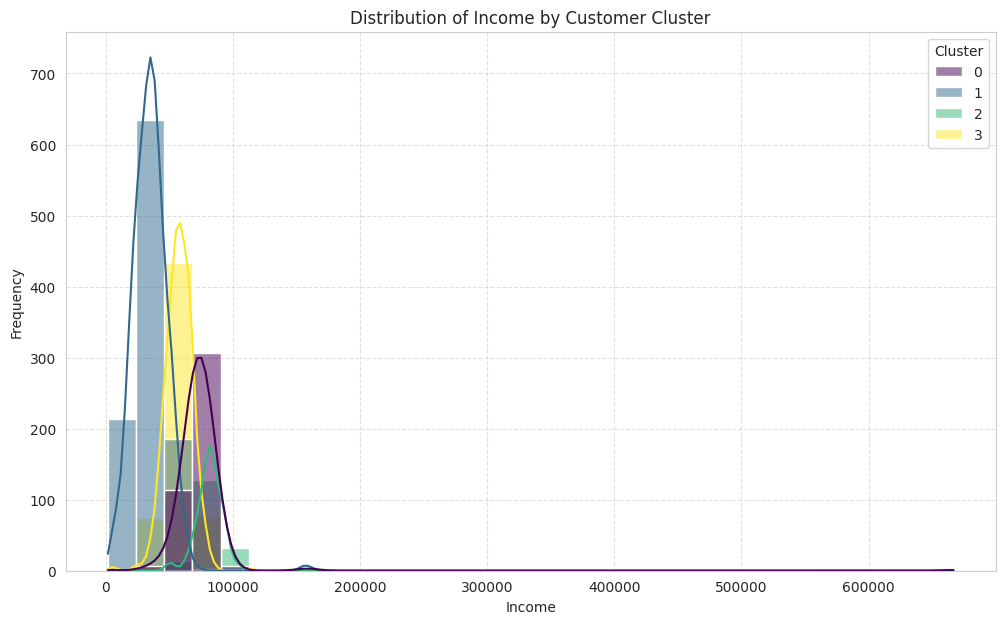

In [ ]:
plt.figure(figsize=(12, 7))
sns.histplot(data=df, x='Income', hue='Cluster', kde=True, palette='viridis', bins=30)
plt.title('Distribution of Income by Customer Cluster')
plt.xlabel('Income')
plt.ylabel('Frequency')
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

### Customer Cluster Profiles

Below is a table summarizing the mean characteristics of each customer cluster. This table serves as the basis for defining the profiles of our customer segments.

In [ ]:
display(cluster_analysis)

,Income,Age,Kidhome,Teenhome,Recency,MntWines,MntFruits,MntMeatProducts,MntFishProducts,MntSweetProducts,...,NumStorePurchases,NumWebVisitsMonth,AcceptedCmp1,AcceptedCmp2,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,Response,Complain,TotalMnt
Cluster,,,,,,,,,,,,,,,,,,,,,
0,74375.974383,56.061503,0.050114,0.220957,49.621868,509.574032,72.435080,438.949886,106.275626,70.733485,...,8.412301,2.947608,0.111617,0.000000,0.061503,0.027335,0.000000,0.175399,0.006834,1276.840547
1,35060.145208,52.412500,0.800000,0.442308,49.498077,41.792308,5.000962,23.473077,7.242308,5.074038,...,3.210577,6.467308,0.000962,0.001923,0.074038,0.008654,0.000000,0.092308,0.012500,97.935577
2,81469.985565,54.485549,0.052023,0.132948,49.872832,878.734104,55.942197,466.242775,76.485549,65.086705,...,8.213873,3.052023,0.439306,0.127168,0.138728,0.398844,0.930636,0.578035,0.005780,1619.872832
3,57527.094829,59.675170,0.224490,0.942177,47.814626,444.945578,20.814626,129.586735,28.295918,22.163265,...,7.681973,5.715986,0.030612,0.010204,0.059524,0.130952,0.003401,0.103741,0.006803,704.700680


Based on the mean values in the `cluster_analysis` table, we can define the following customer profiles:

**Cluster 0: "Affluent & Engaged Singles/Couples"**
*   **Income**: High income, second highest after Cluster 2.
*   **Age**: Middle-aged customers.
*   **Family**: Very few kids or teens at home.
*   **Spending**: High spending across all product categories, especially wines and meat. High `TotalMnt`.
*   **Purchases**: High numbers of web, catalog, and store purchases.
*   **Campaigns**: Show higher acceptance rates for past campaigns compared to clusters 1 and 3.
*   **Profile**: These customers are likely established, financially stable individuals or couples without many dependent children. They are active purchasers and responsive to marketing efforts, indicating a strong engagement with the brand and its offerings.

**Cluster 1: "Budget-Conscious Young Families"**
*   **Income**: Lowest income among all clusters.
*   **Age**: Youngest customer segment.
*   **Family**: High number of kids and teens at home.
*   **Spending**: Very low spending across all product categories, resulting in the lowest `TotalMnt`.
*   **Purchases**: Low numbers of purchases across all channels.
*   **Campaigns**: Low acceptance rates for previous campaigns.
*   **Profile**: This segment consists of younger families with significant household responsibilities, likely on a tighter budget. Their purchasing behavior is minimal, suggesting price sensitivity and a need for value-oriented offers or different product positioning.

**Cluster 2: "High-Value Elite Patrons"**
*   **Income**: Highest average income among all clusters.
*   **Age**: Middle-aged to slightly older, similar to Cluster 0.
*   **Family**: Very few children or teenagers at home.
*   **Spending**: Exceptionally high spending in all product categories, particularly wines and meat, leading to the highest `TotalMnt`.
*   **Purchases**: Very high numbers of catalog and store purchases, and high web purchases.
*   **Campaigns**: Highest acceptance rates for campaigns (especially AcceptedCmp5).
*   **Profile**: These are the most valuable customers, characterized by high disposable income and significant purchasing power. They are likely established, enjoy luxury, and respond well to curated, high-end offerings and exclusive campaigns. They are brand loyal and are a primary target for premium products.

**Cluster 3: "Established Older Families"**
*   **Income**: Mid-to-high income, positioned above Cluster 1 but below Clusters 0 and 2.
*   **Age**: Oldest customer segment.
*   **Family**: High number of teenagers at home, and some kids.
*   **Spending**: Moderate spending across product categories, with a good amount spent on wines and meat, but overall lower than Clusters 0 and 2.
*   **Purchases**: Moderate numbers of purchases across channels.
*   **Campaigns**: Moderate acceptance rates for previous campaigns.
*   **Profile**: This segment represents older, established families, possibly with adult or near-adult children still at home. They have comfortable incomes but their spending patterns might be influenced by ongoing family expenses or a more settled lifestyle. They represent a stable, but perhaps less impulsive, customer base.

### Average Response Rate by Customer Cluster

To understand which clusters are most responsive to marketing campaigns, we'll calculate the average response rate for each segment.

,Cluster,Response,Response_Rate_%
2,2,0.578035,57.803468
0,0,0.175399,17.539863
3,3,0.103741,10.374150
1,1,0.092308,9.230769


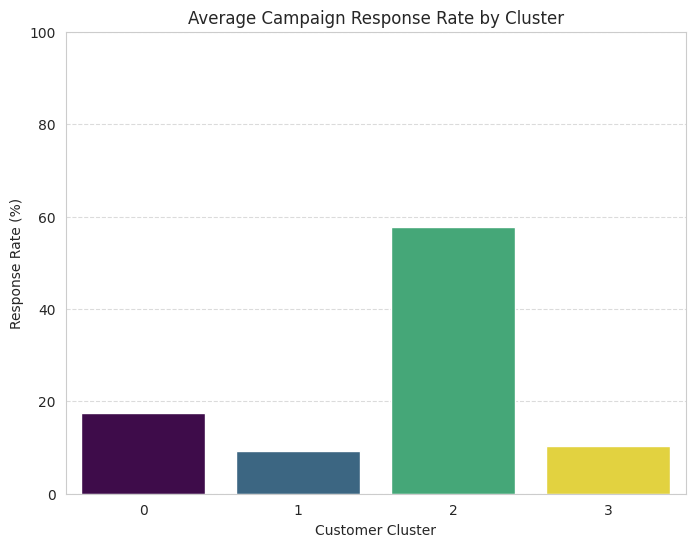

In [ ]:
# Calculate the average response rate (mean of 'Response' column) for each cluster
response_rate_by_cluster = df.groupby('Cluster')['Response'].mean().reset_index()
response_rate_by_cluster['Response_Rate_%'] = response_rate_by_cluster['Response'] * 100

display(response_rate_by_cluster.sort_values(by='Response_Rate_%', ascending=False))

# Optionally, visualize this
plt.figure(figsize=(8, 6))
sns.barplot(x='Cluster', y='Response_Rate_%', data=response_rate_by_cluster, palette='viridis', hue='Cluster', legend=False)
plt.title('Average Campaign Response Rate by Cluster')
plt.xlabel('Customer Cluster')
plt.ylabel('Response Rate (%)')
plt.ylim(0, 100)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()